Instalasi Library

In [1]:
!pip install ultralytics opencv-python matplotlib


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 915.3/915.3 kB 15.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 39.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 30.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 36.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 2.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 5.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 12.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 6.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 91.9 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstall

Import Library dan Cek GPU

In [2]:
import cv2
import torch
import matplotlib.pyplot as plt
from ultralytics import YOLO
from IPython.display import Image, display
import itertools
import glob

# Pastikan Matplotlib berjalan dengan lancar
%matplotlib inline

# Cek apakah GPU tersedia
print("GPU Available:", torch.cuda.is_available())

# Fungsi membaca gambar
def imread(path):
    return cv2.imread(path)

# Fungsi menyimpan gambar
def imwrite(img, path):
    if cv2.imwrite(path, img):
        print(f'✅ Gambar berhasil disimpan ke "{path}"')
    else:
        print(f'❌ Gagal menyimpan gambar ke "{path}"')

# Fungsi menampilkan gambar dengan Matplotlib
def imshow(img, figsize=(10, 10), is_bgr=True):
    if is_bgr:
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
    plt.figure(figsize=figsize)
    plt.imshow(img)
    plt.axis("off")
    plt.show()


Creating new Ultralytics Settings v0.0.6 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
GPU Available: True


Prediksi Gambar

100%|██████████| 6.25M/6.25M [00:00<00:00, 119MB/s]

WARNING ⚠️ 'source' is missing. Using 'source=/usr/local/lib/python3.11/dist-packages/ultralytics/assets'.



image 1/2 /usr/local/lib/python3.11/dist-packages/ultralytics/assets/bus.jpg: 640x480 3 persons, 1 bus, 40.4ms
image 2/2 /usr/local/lib/python3.11/dist-packages/ultralytics/assets/zidane.jpg: 384x640 2 persons, 50.1ms
Speed: 8.4ms preprocess, 45.3ms inference, 154.1ms postprocess per image at shape (1, 3, 384, 640)


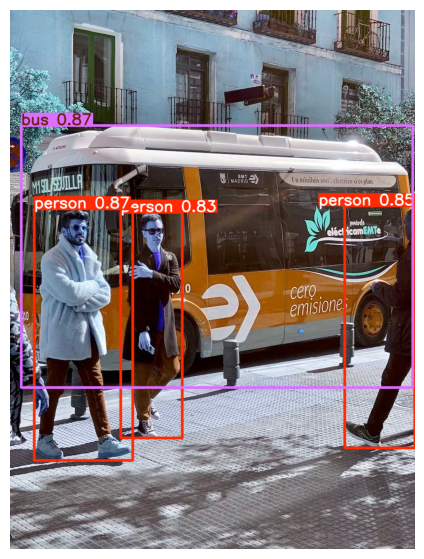

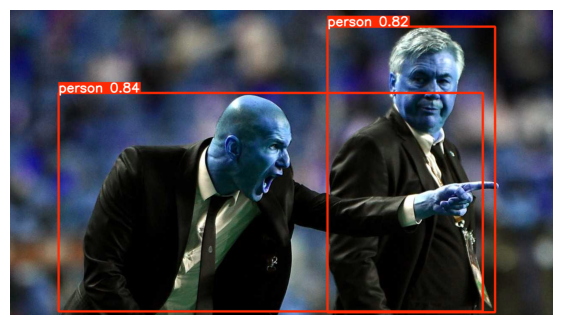

✅ Gambar berhasil disimpan ke "result.jpg"


In [3]:
# Load model YOLOv8n
model = YOLO("yolov8n.pt")

# 🔍 Prediksi pada gambar
img = imread('test.jpg')
results = model.predict(img, conf=0.5)

# 🎨 Tampilkan hasil deteksi
for result in results:
    imshow(result.plot(), figsize=(7, 7), is_bgr=False)

# 🖼 Simpan hasil deteksi ke file
imwrite(results[0].plot(), "result.jpg")


Deteksi dengan Webcam (Opsional)

In [4]:
# 📹 Jalankan deteksi real-time menggunakan Webcam
cap = cv2.VideoCapture(0)  # 0 = default webcam

while cap.isOpened():
    ret, frame = cap.read()
    if not ret:
        break

    results = model.predict(frame, conf=0.5)  # Prediksi YOLO pada webcam
    for result in results:
        frame = result.plot()

    cv2.imshow("YOLOv8 Detection", frame)

    if cv2.waitKey(1) & 0xFF == ord("q"):
        break

cap.release()
cv2.destroyAllWindows()


Hyperparameter Tuning (Grid Search)

In [7]:
import itertools
import torch
from ultralytics import YOLO

# 🔍 Cek apakah GPU tersedia
device = "cuda" if torch.cuda.is_available() else "cpu"

# 🔍 Hyperparameter Tuning menggunakan Grid Search
param_grid = {
    "lr0": [1e-3, 1e-4],
    "momentum": [0.8, 0.9],
    "batch": [8, 16]
}

# Generate kombinasi parameter
combinations = list(itertools.product(*param_grid.values()))

best_model = None
best_mAP = 0

# Load model sekali saja, lalu buat copy-nya untuk setiap iterasi
# Instead of copying the model, reload it for each iteration
for params in combinations:
    lr0, momentum, batch = params
    print(f"🚀 Training with: lr0={lr0}, momentum={momentum}, batch={batch}")

    # Load a fresh model for each iteration
    model = YOLO("yolov8n.pt")

    results = model.train(
        data="coco128.yaml",
        epochs=5,
        imgsz=640,
        lr0=lr0,
        momentum=momentum,
        batch=batch,
        device=device
    )

    # Evaluasi dengan mAP, gunakan .get() untuk menghindari error
    mAP = results.results_dict.get("metrics/mAP50-95(B)", 0)

    if mAP > best_mAP:
        best_mAP = mAP
        best_model = model

        # Simpan model terbaik dalam format ONNX & PT dengan nama yang jelas
        best_model.export(format="onnx")
        best_model.save(f"best_model_lr{lr0}_momentum{momentum}_batch{batch}.pt")

    # Bersihkan cache untuk mencegah OOM
    del model
    torch.cuda.empty_cache()

print(f"✅ Best model found with mAP: {best_mAP}")

🚀 Training with: lr0=0.001, momentum=0.8, batch=8
Ultralytics 8.3.77 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
engine/trainer: task=detect, mode=train, model=yolov8n.pt, data=coco128.yaml, epochs=5, time=None, patience=100, batch=8, imgsz=640, save=True, save_period=-1, cache=False, device=cuda, workers=8, project=None, name=train, exist_ok=False, pretrained=True, optimizer=auto, verbose=True, seed=0, deterministic=True, single_cls=False, rect=False, cos_lr=False, close_mosaic=10, resume=False, amp=True, fraction=1.0, profile=False, freeze=None, multi_scale=False, overlap_mask=True, mask_ratio=4, dropout=0.0, val=True, split=val, save_json=False, save_hybrid=False, conf=None, iou=0.7, max_det=300, half=False, dnn=False, plots=True, source=None, vid_stride=1, stream_buffer=False, visualize=False, augment=False, agnostic_nms=False, classes=None, retina_masks=False, embed=None, show=False, save_frames=False, save_txt=False, save_conf=False, save_crop=False, show_label

100%|██████████| 6.66M/6.66M [00:00<00:00, 101MB/s]
Unzipping /content/datasets/coco128.zip to /content/datasets/coco128...: 100%|██████████| 263/263 [00:00<00:00, 4110.36file/s]

Dataset download success ✅ (1.0s), saved to /content/datasets



100%|██████████| 755k/755k [00:00<00:00, 21.2MB/s]



                   from  n    params  module                                       arguments                     
  0                  -1  1       464  ultralytics.nn.modules.conv.Conv             [3, 16, 3, 2]                 
  1                  -1  1      4672  ultralytics.nn.modules.conv.Conv             [16, 32, 3, 2]                
  2                  -1  1      7360  ultralytics.nn.modules.block.C2f             [32, 32, 1, True]             
  3                  -1  1     18560  ultralytics.nn.modules.conv.Conv             [32, 64, 3, 2]                
  4                  -1  2     49664  ultralytics.nn.modules.block.C2f             [64, 64, 2, True]             
  5                  -1  1     73984  ultralytics.nn.modules.conv.Conv             [64, 128, 3, 2]               
  6                  -1  2    197632  ultralytics.nn.modules.block.C2f             [128, 128, 2, True]           
  7                  -1  1    295424  ultralytics.nn.modules.conv.Conv             [128

...

        5/5      2.54G      1.138      1.376      1.219        276        640: 100%|██████████| 8/8 [00:01<00:00,  4.09it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:01<00:00,  3.73it/s]

                   all        128        929      0.735      0.547      0.649      0.488



5 epochs completed in 0.007 hours.
Optimizer stripped from runs/detect/train8/weights/last.pt, 6.5MB
Optimizer stripped from runs/detect/train8/weights/best.pt, 6.5MB

Validating runs/detect/train8/weights/best.pt...
Ultralytics 8.3.77 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs


                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 4/4 [00:02<00:00,  1.53it/s]


                   all        128        929      0.736      0.547      0.649      0.488
                person         61        254      0.848      0.637      0.772      0.546
               bicycle          3          6          1      0.332      0.382      0.333
                   car         12         46      0.923      0.217      0.298      0.194
            motorcycle          4          5      0.674        0.8      0.938      0.731
              airplane          5          6      0.711      0.833      0.913      0.715
                   bus          5          7      0.709      0.714      0.731      0.662
                 train          3          3      0.678      0.667      0.913      0.821
                 truck          5         12          1      0.461      0.526      0.315
                  boat          2          6       0.36      0.193      0.445      0.251
         traffic light          4         14      0.684      0.157      0.206       0.14
             stop sig

In [9]:
import glob
model_files = glob.glob("**/*.pt", recursive=True)
print("Model yang ditemukan:", model_files)


Model yang ditemukan: ['yolo11n.pt', 'best_model_lr0.001_momentum0.8_batch8.pt', 'yolov8n.pt', 'runs/detect/train2/weights/best.pt', 'runs/detect/train2/weights/last.pt', 'runs/detect/train5/weights/best.pt', 'runs/detect/train5/weights/last.pt', 'runs/detect/train8/weights/best.pt', 'runs/detect/train8/weights/last.pt', 'runs/detect/train4/weights/best.pt', 'runs/detect/train4/weights/last.pt', 'runs/detect/train6/weights/best.pt', 'runs/detect/train6/weights/last.pt', 'runs/detect/train7/weights/best.pt', 'runs/detect/train7/weights/last.pt', 'runs/detect/train3/weights/best.pt', 'runs/detect/train3/weights/last.pt', 'runs/detect/train/weights/best.pt', 'runs/detect/train/weights/last.pt']


In [10]:
from ultralytics import YOLO

best_model_path = "runs/detect/train8/weights/best.pt"  # Sesuaikan dengan yang terbaik
best_model = YOLO(best_model_path)

results = best_model.val(data="coco128.yaml")
print("Hasil Evaluasi:", results.results_dict)


Ultralytics 8.3.77 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs


val: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100%|██████████| 128/128 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:03<00:00,  2.61it/s]


                   all        128        929      0.704      0.565       0.65      0.487
                person         61        254      0.825      0.667      0.776      0.545
               bicycle          3          6      0.569      0.333      0.381      0.333
                   car         12         46      0.844      0.217      0.294       0.19
            motorcycle          4          5      0.674      0.831      0.938      0.731
              airplane          5          6      0.692      0.833      0.913      0.715
                   bus          5          7      0.693      0.714      0.731      0.662
                 train          3          3      0.677      0.706      0.913      0.821
                 truck          5         12          1      0.477      0.526      0.328
                  boat          2          6       0.39      0.167      0.363      0.196
         traffic light          4         14      0.711      0.181      0.206       0.14
             stop sig

Evaluasi Model

Ultralytics 8.3.77 🚀 Python-3.11.11 torch-2.5.1+cu124 CUDA:0 (Tesla T4, 15095MiB)
Model summary (fused): 72 layers, 3,151,904 parameters, 0 gradients, 8.7 GFLOPs


val: Scanning /content/datasets/coco128/labels/train2017.cache... 126 images, 2 backgrounds, 0 corrupt: 100%|██████████| 128/128 [00:00<?, ?it/s]
                 Class     Images  Instances      Box(P          R      mAP50  mAP50-95): 100%|██████████| 8/8 [00:02<00:00,  2.68it/s]


                   all        128        929      0.704      0.565       0.65      0.487
                person         61        254      0.825      0.667      0.776      0.545
               bicycle          3          6      0.569      0.333      0.381      0.333
                   car         12         46      0.844      0.217      0.294       0.19
            motorcycle          4          5      0.674      0.831      0.938      0.731
              airplane          5          6      0.692      0.833      0.913      0.715
                   bus          5          7      0.693      0.714      0.731      0.662
                 train          3          3      0.677      0.706      0.913      0.821
                 truck          5         12          1      0.477      0.526      0.328
                  boat          2          6       0.39      0.167      0.363      0.196
         traffic light          4         14      0.711      0.181      0.206       0.14
             stop sig

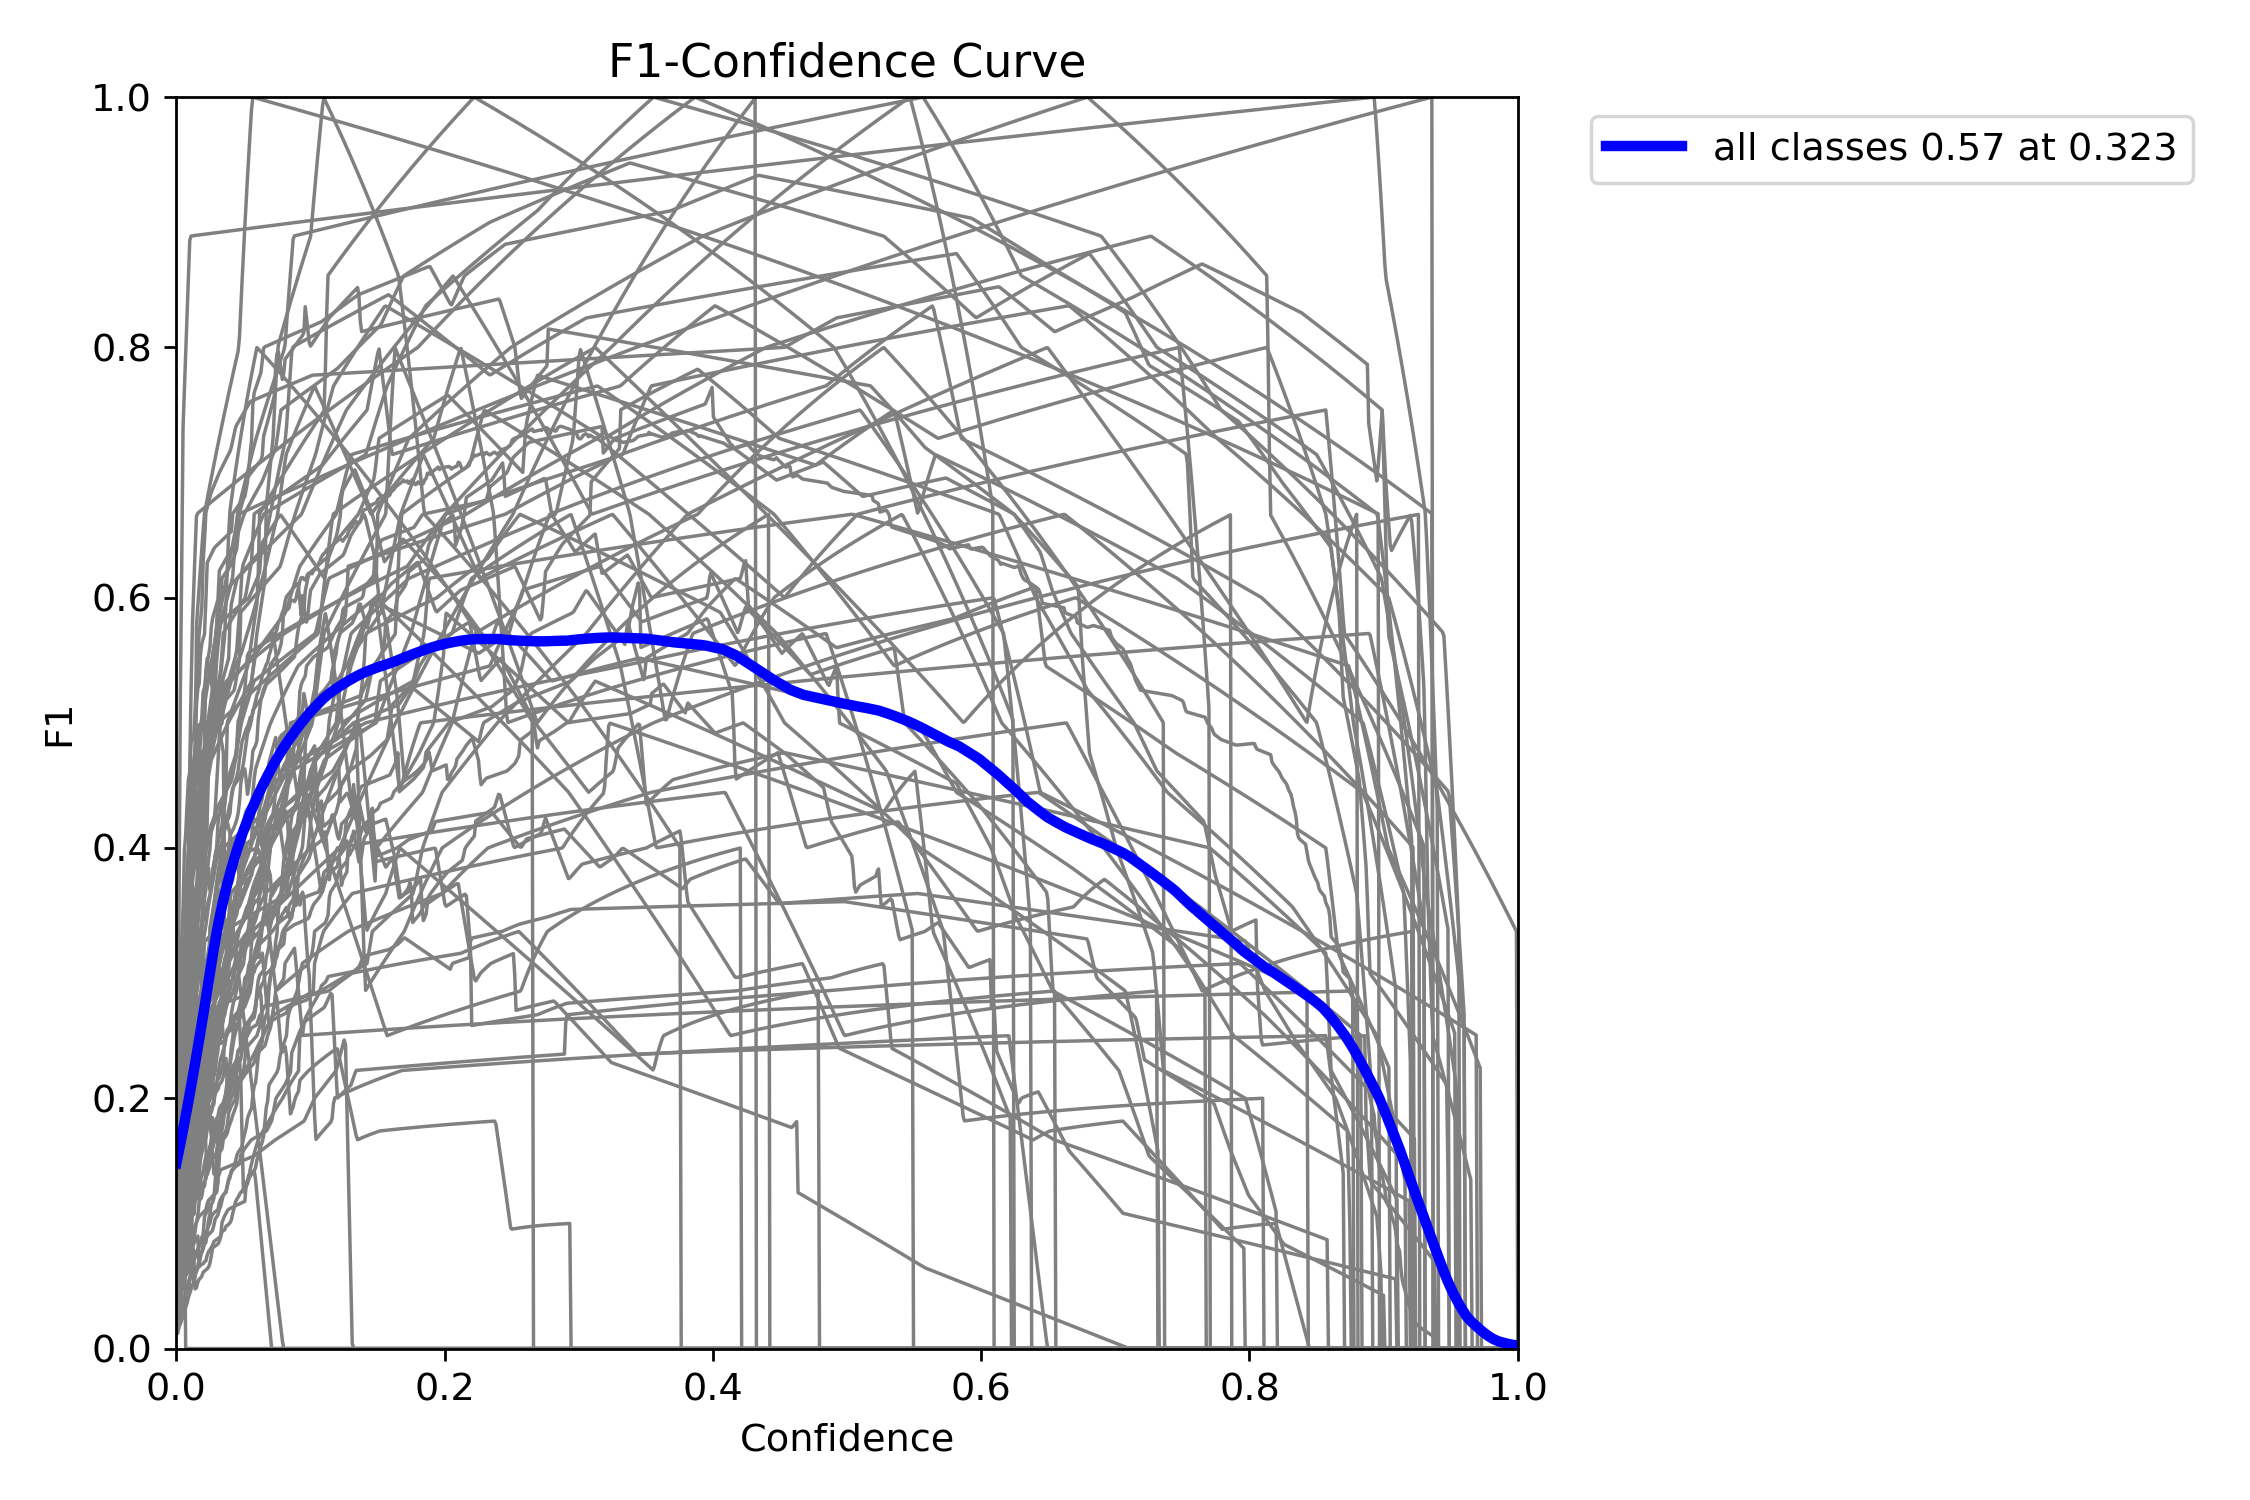

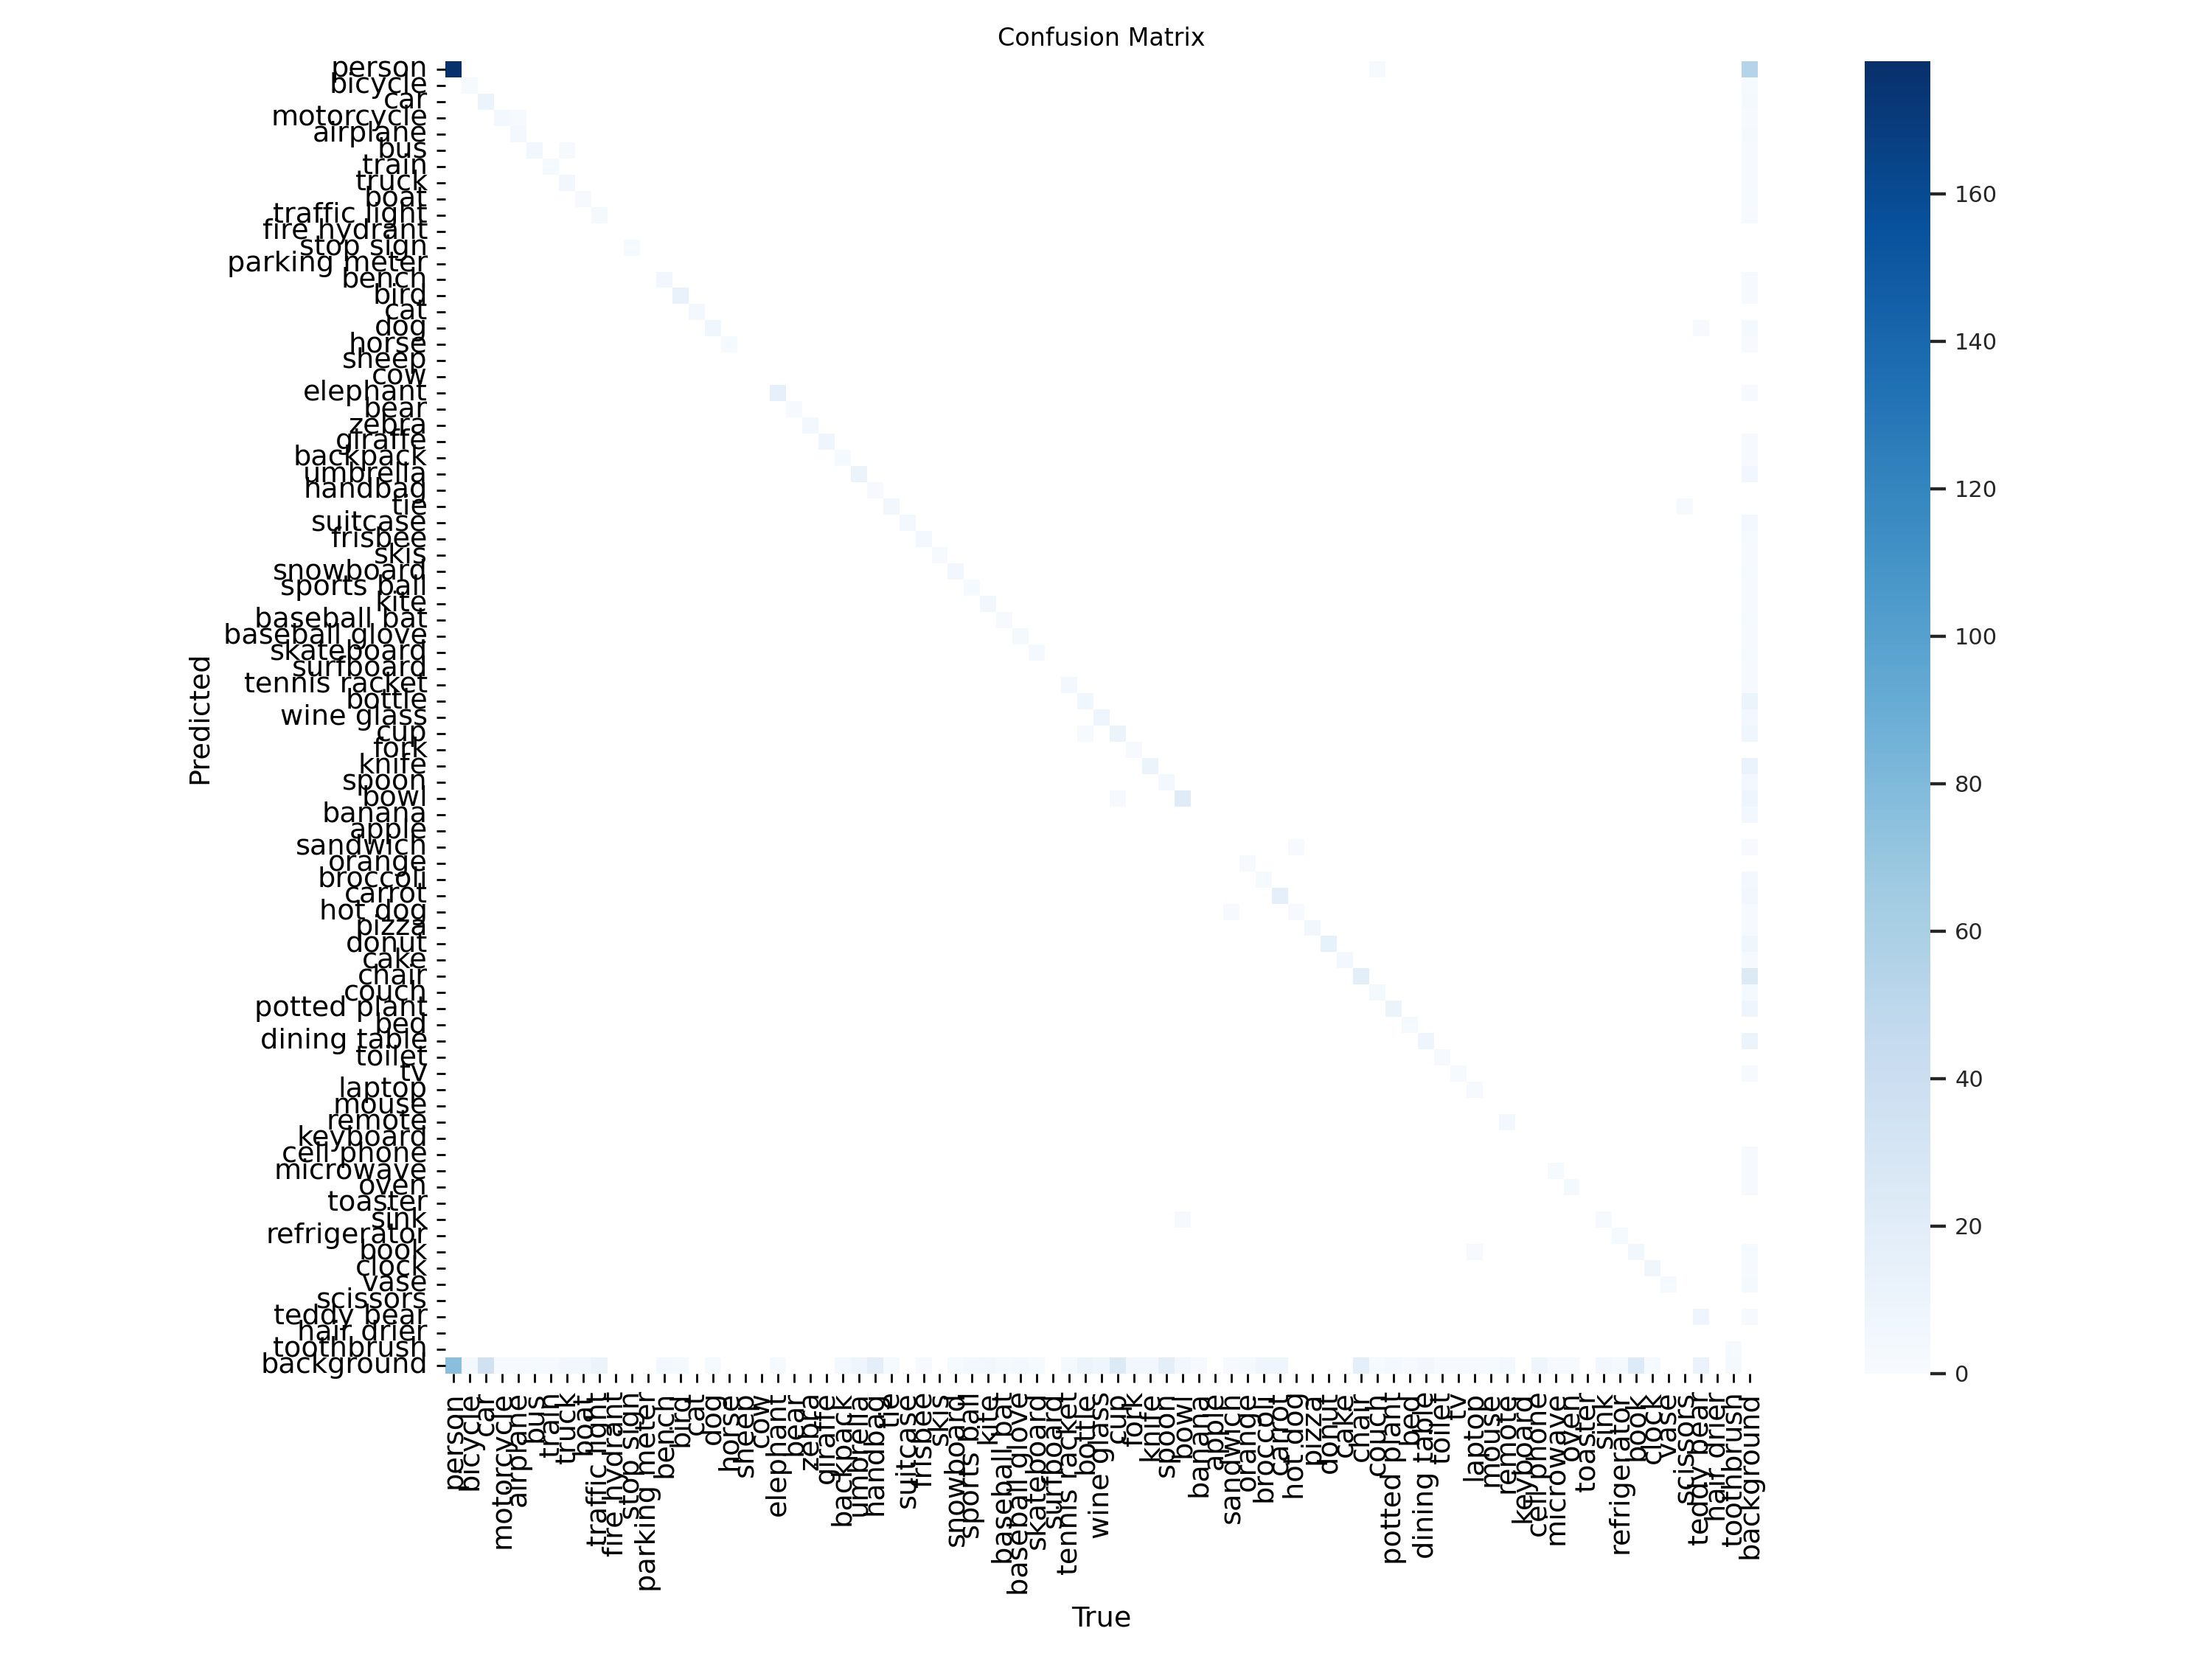

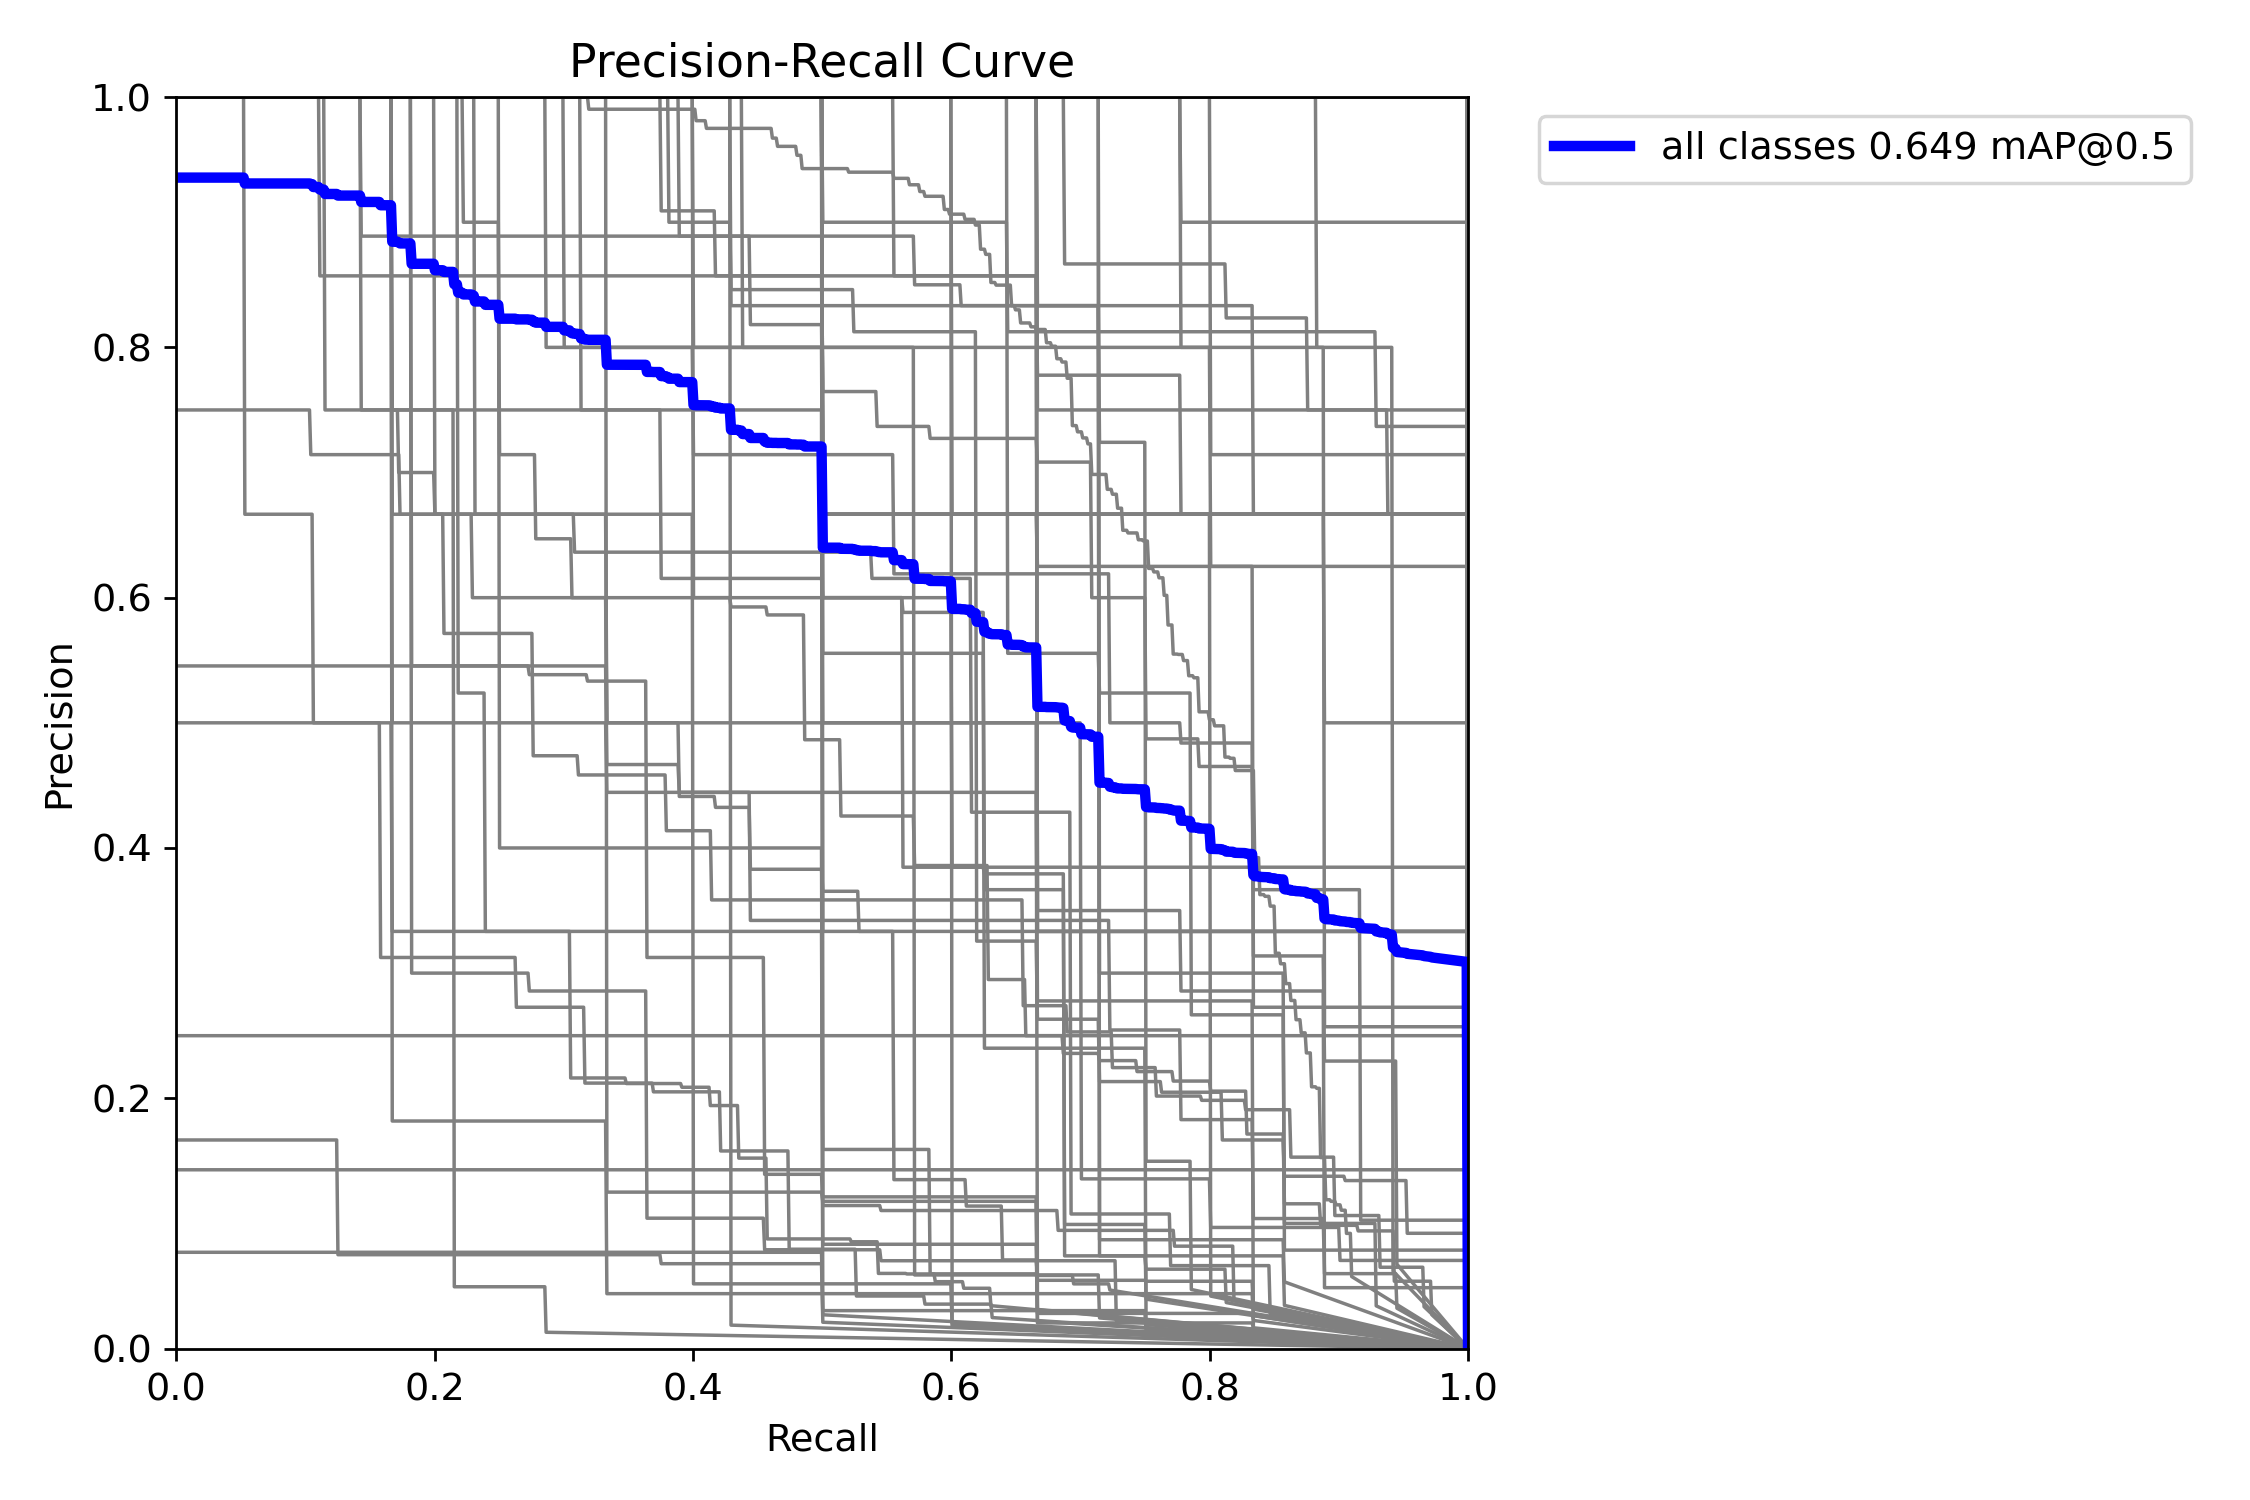

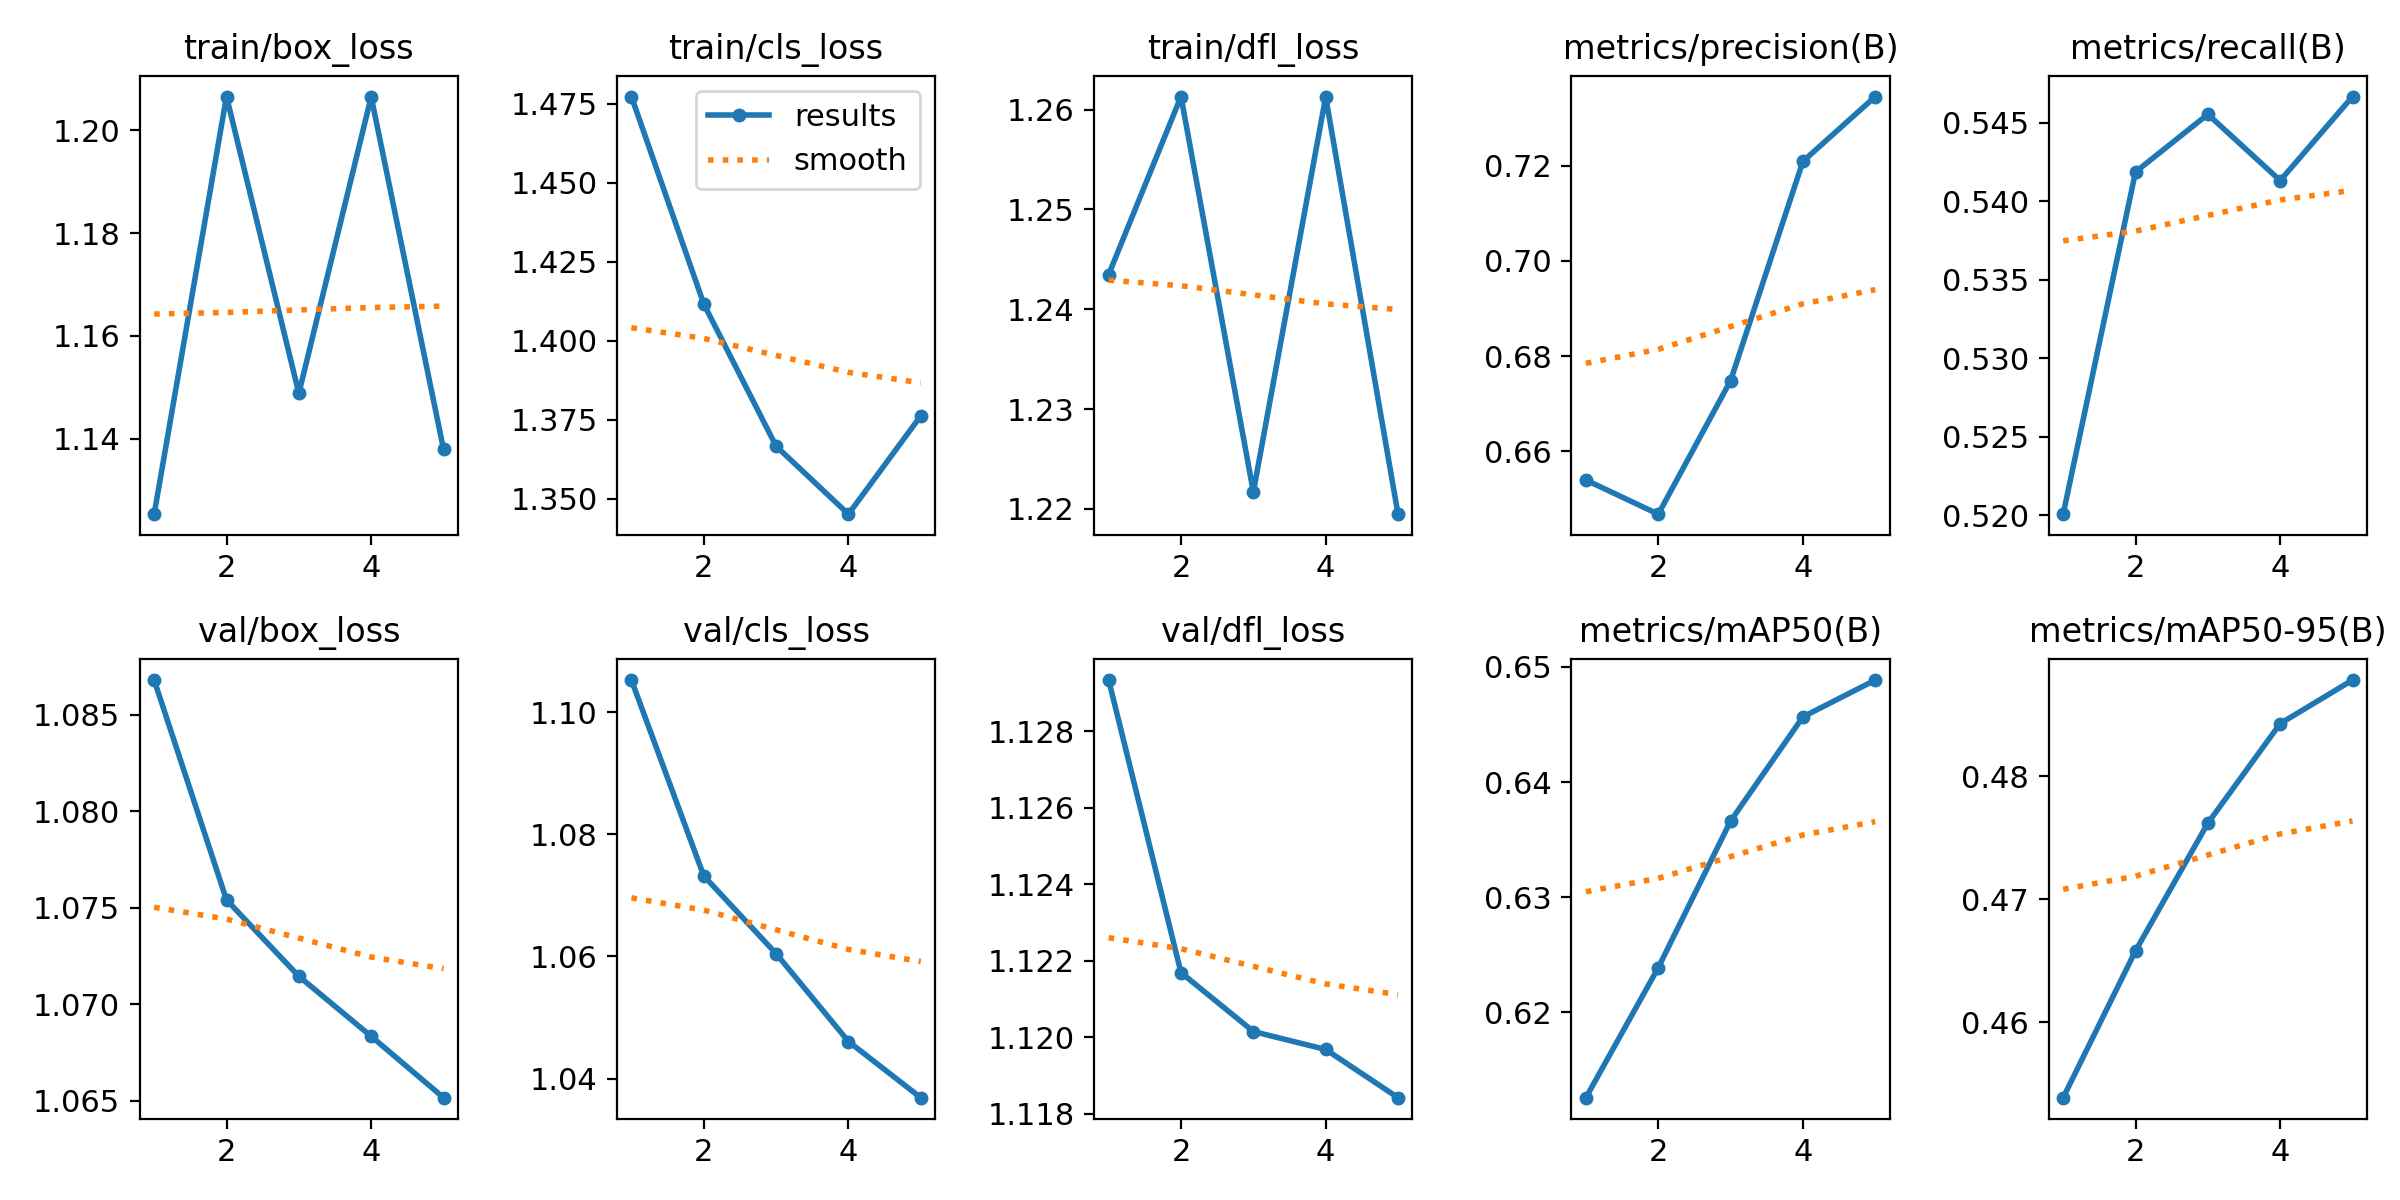

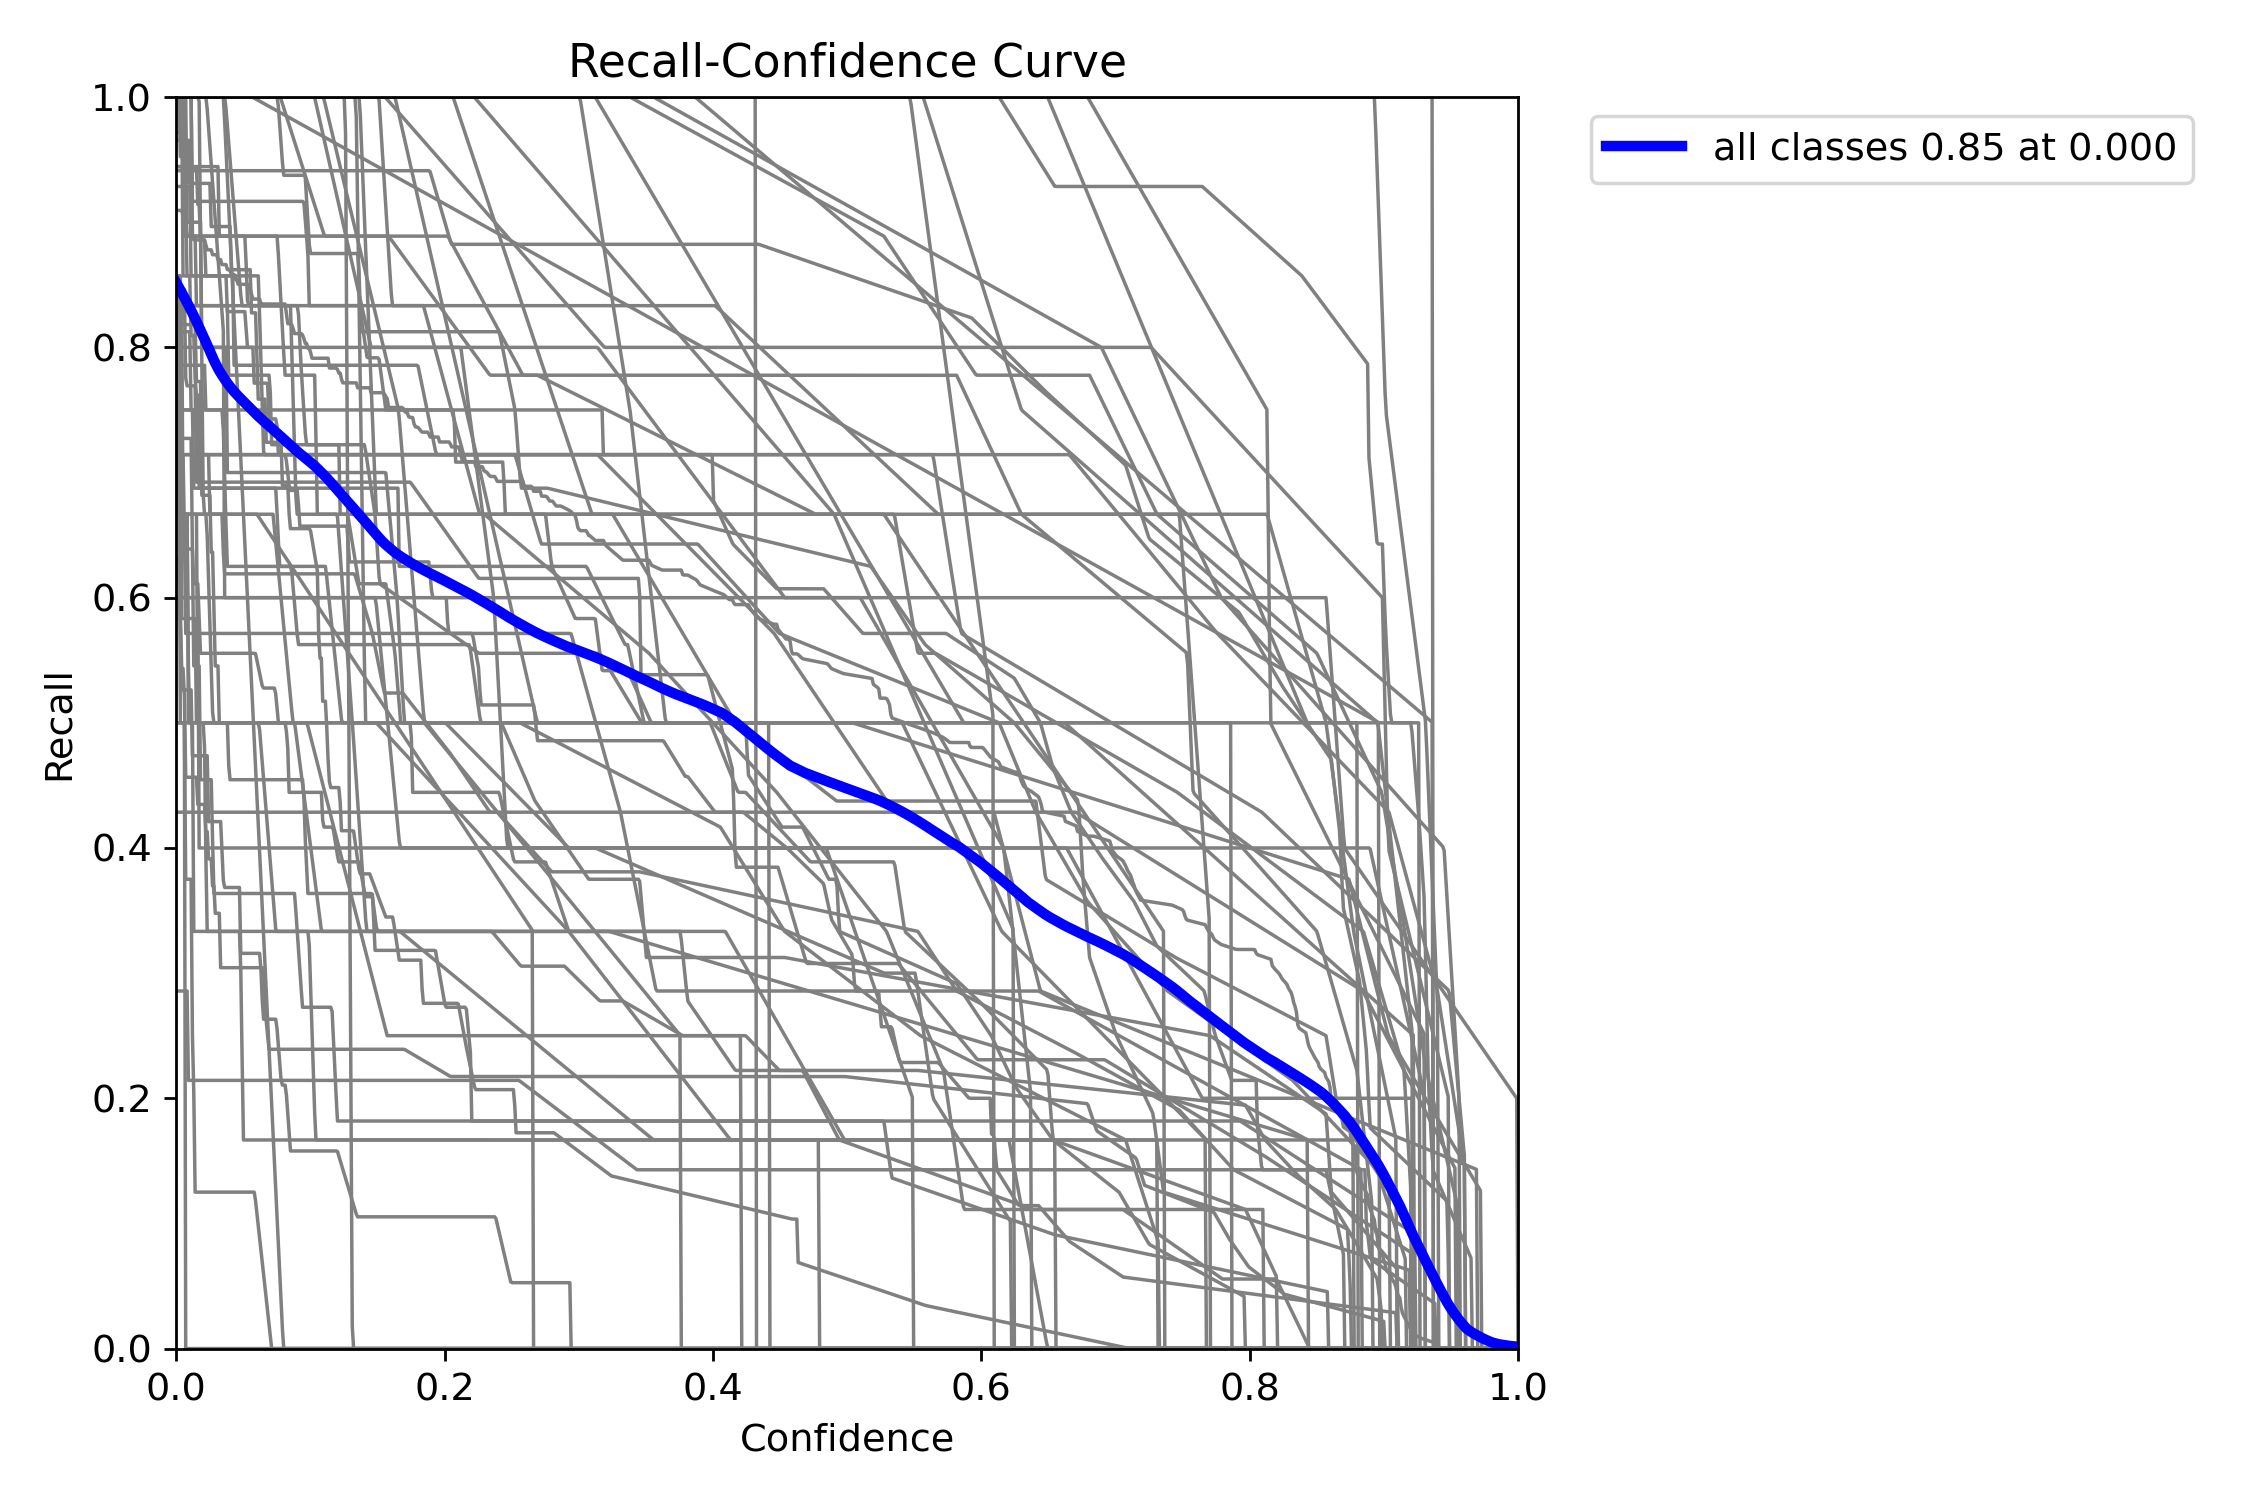

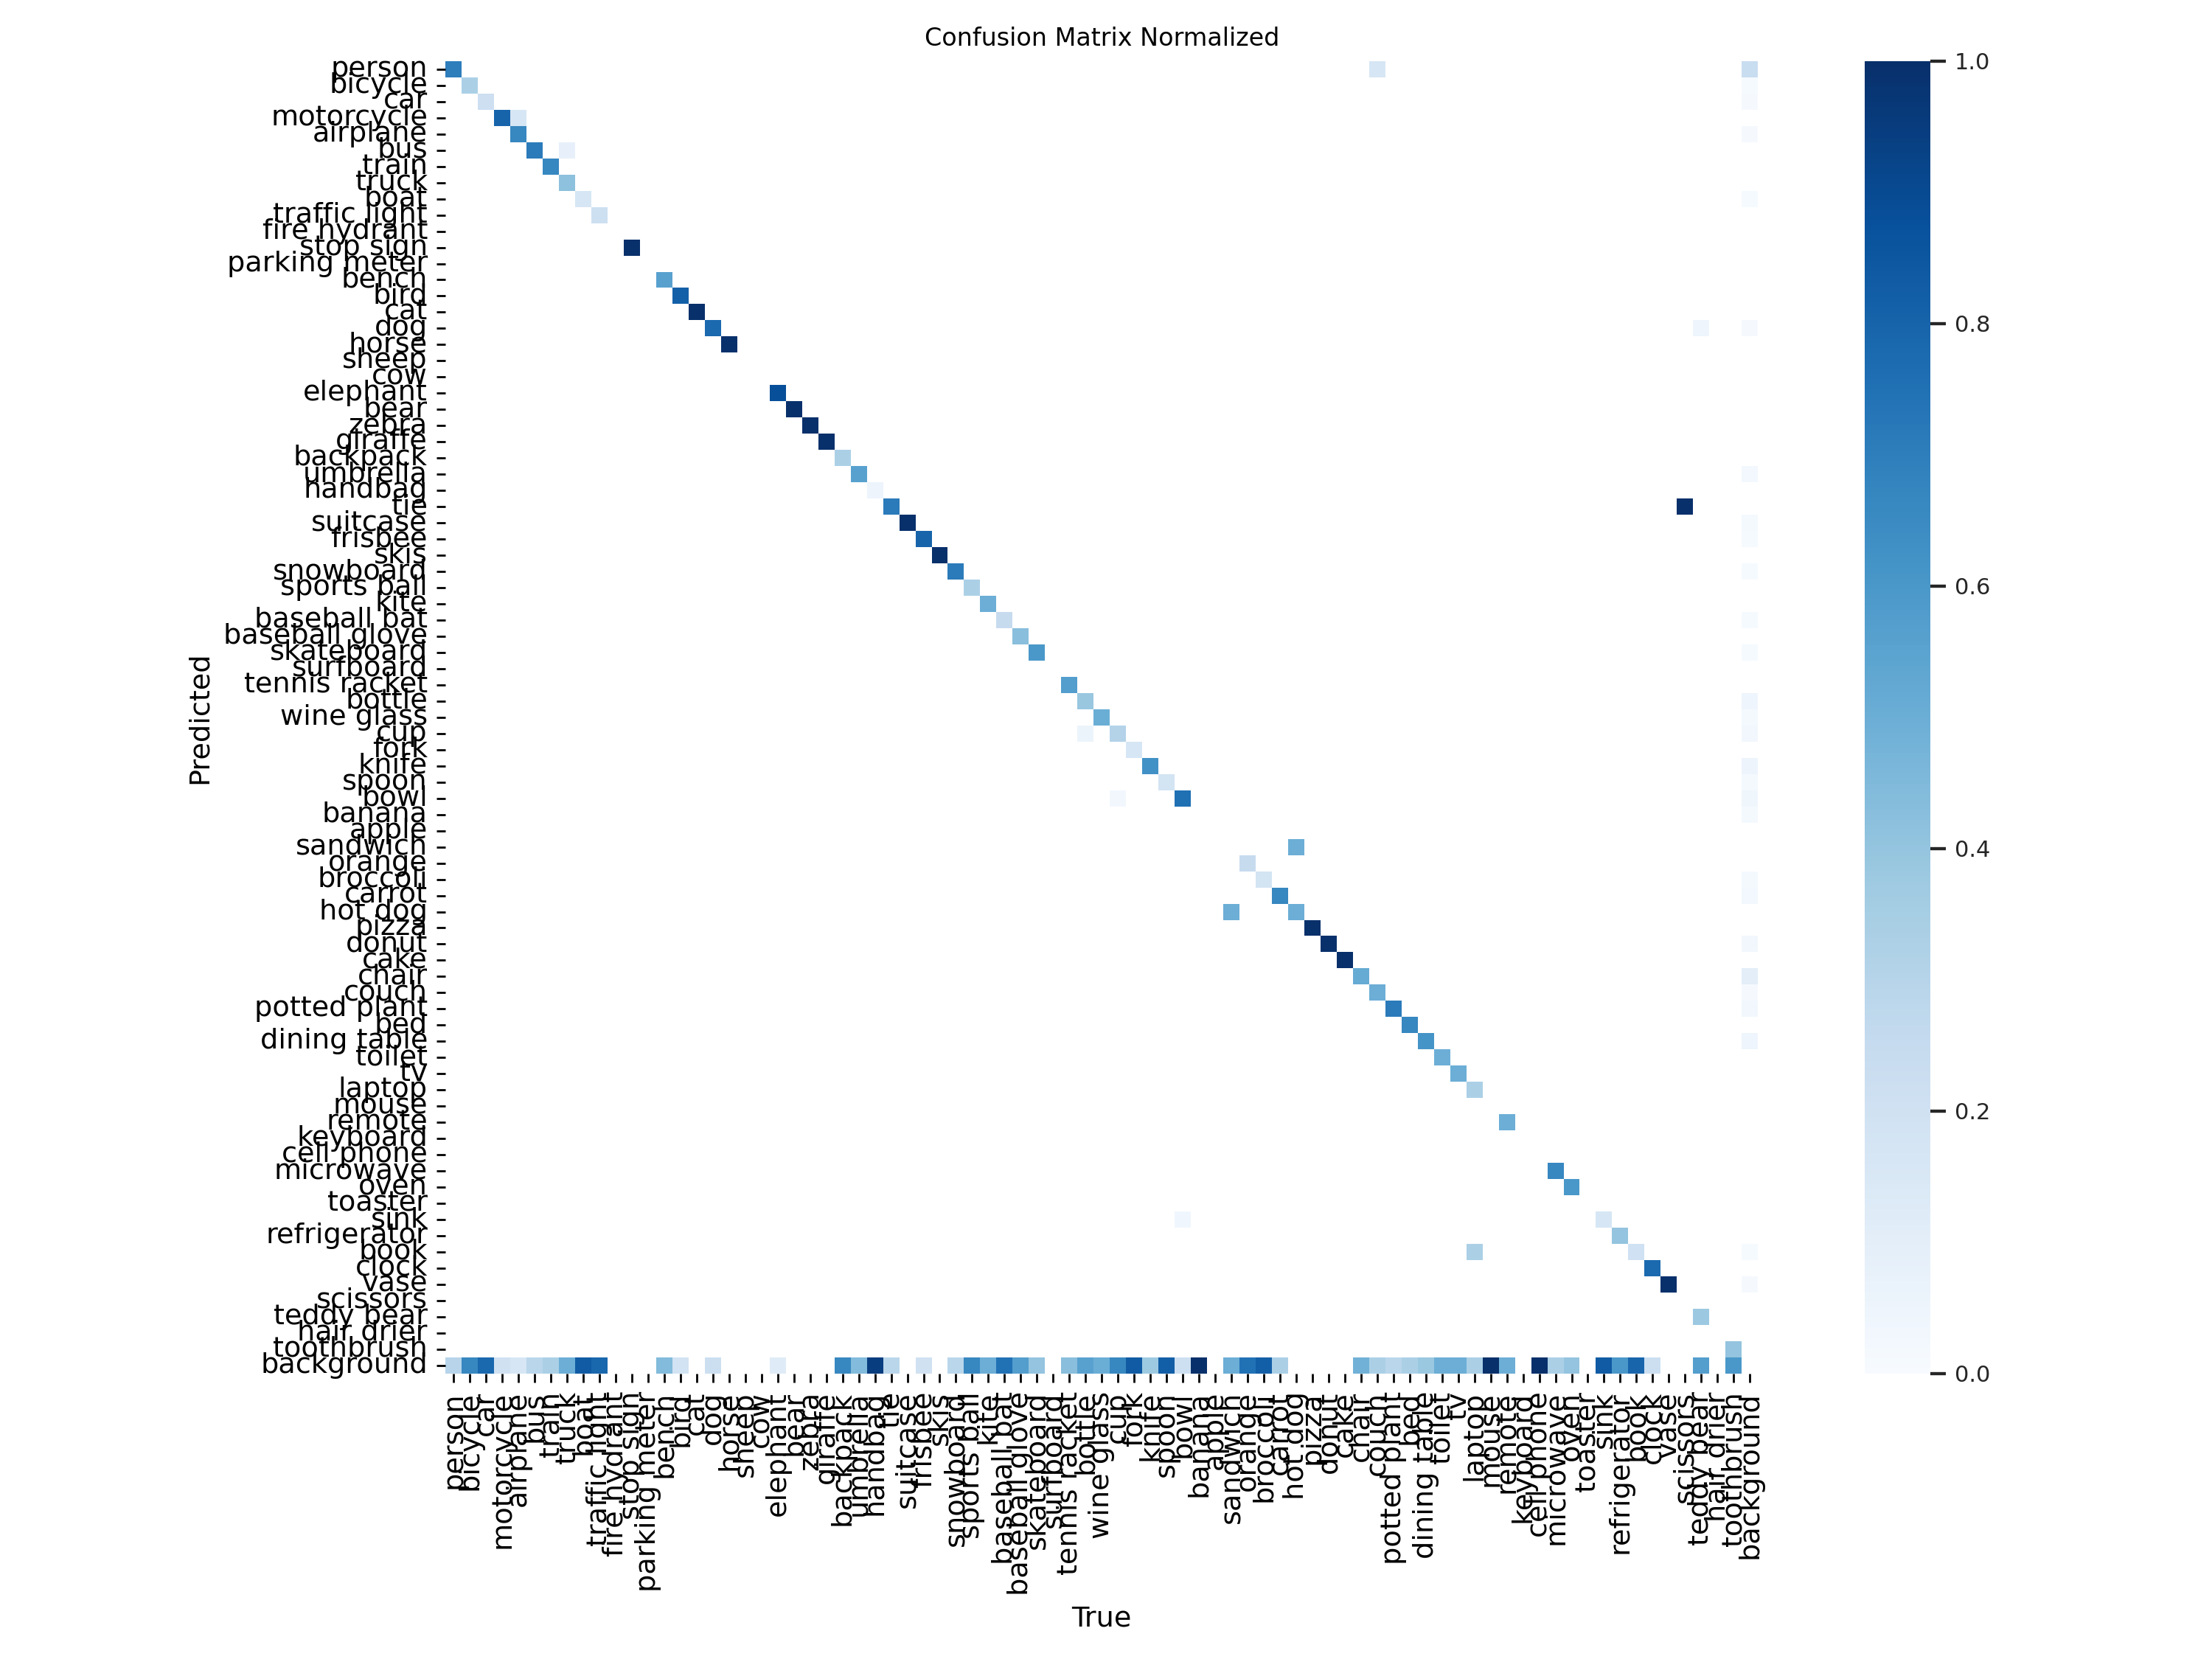

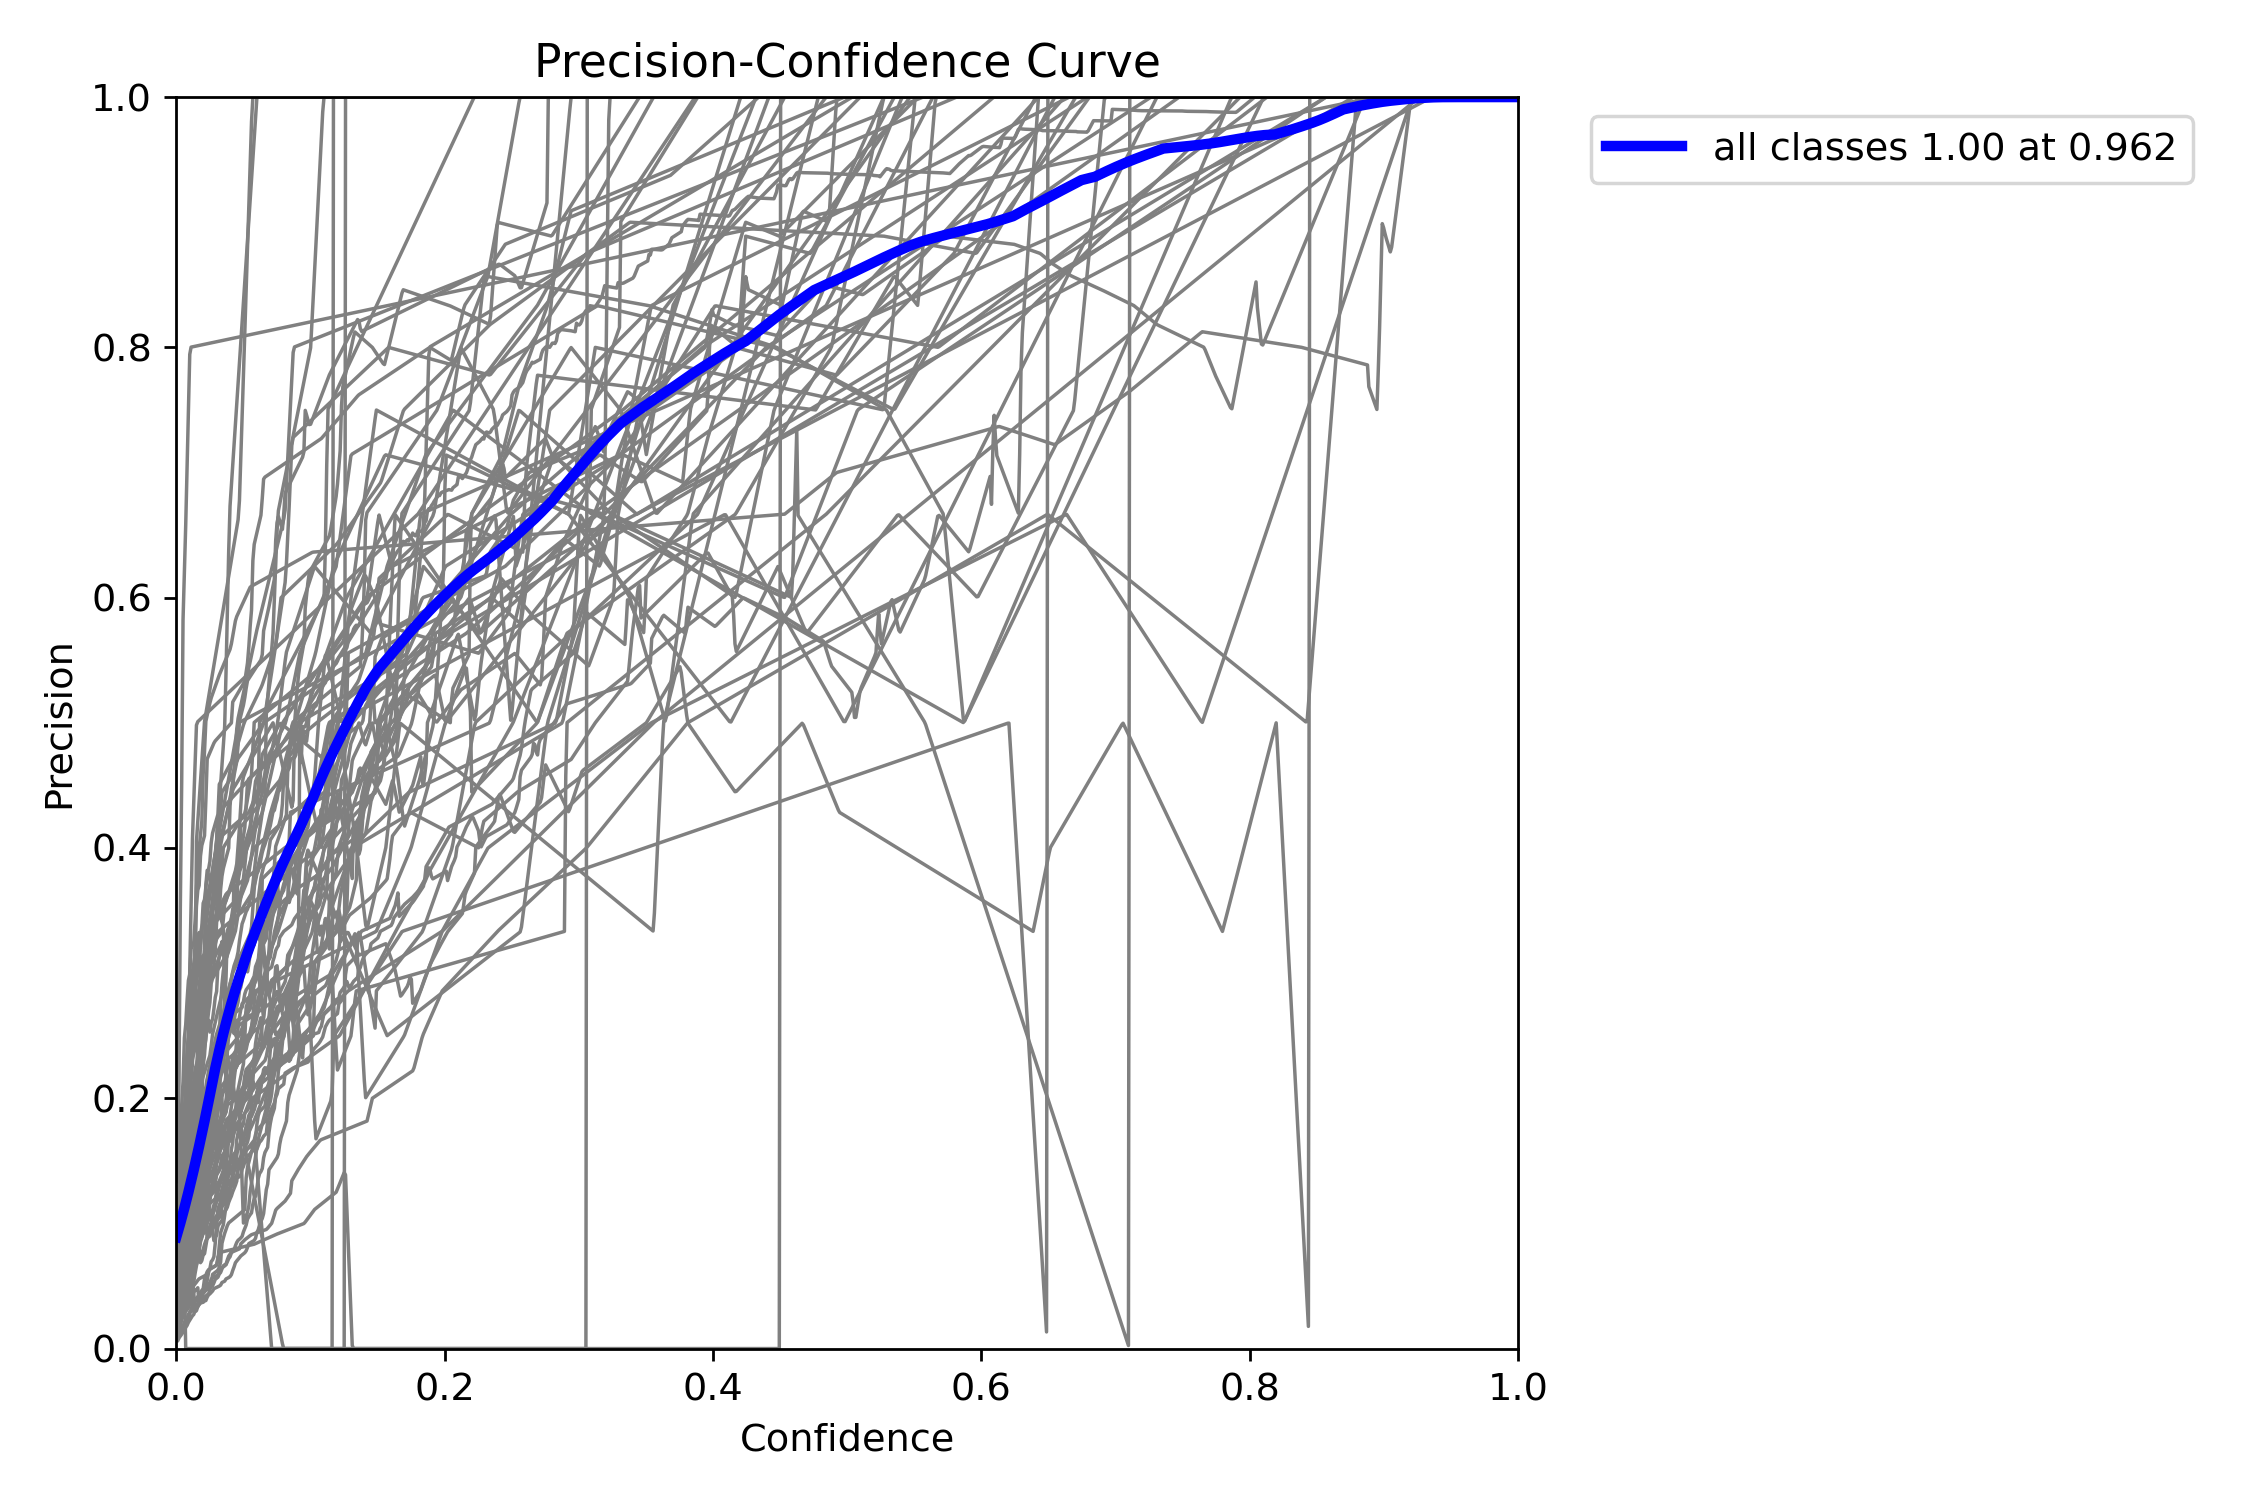

⚠️ Warning: File tidak ditemukan: runs/detect/val/val_batch0.jpg
⚠️ Warning: File tidak ditemukan: runs/detect/val/val_batch1.jpg
⚠️ Warning: File tidak ditemukan: runs/detect/val/val_batch2.jpg
⚠️ Warning: File tidak ditemukan: runs/detect/val/val_batch3.jpg
⚠️ Warning: File tidak ditemukan: runs/detect/val/val_batch4.jpg


In [11]:
from IPython.display import Image, display
import glob
import os
from ultralytics import YOLO

# Pilih model terbaik yang tersedia
best_model_path = "runs/detect/train8/weights/best.pt"  # Sesuaikan dengan model terbaik yang ditemukan

if os.path.exists(best_model_path):
    best_model = YOLO(best_model_path)
    results = best_model.val(data="coco128.yaml")
    print("Hasil Evaluasi:", results.results_dict)

    # 📊 Menampilkan Grafik Training (Loss, Precision, Recall, dll.)
    exp_path = "runs/detect/train8"  # Sesuaikan dengan hasil training yang benar
    images = glob.glob(f"{exp_path}/*.png")

    for img_path in images:
        display(Image(filename=img_path))

    # 🖼 Menampilkan beberapa contoh gambar dari dataset yang digunakan dalam validasi
    for i in range(5):
        img_path = f"runs/detect/val/val_batch{i}.jpg"  # Sesuaikan path validasi
        if os.path.exists(img_path):
            display(Image(filename=img_path))
        else:
            print(f"⚠️ Warning: File tidak ditemukan: {img_path}")
else:
    print("❌ Model terbaik tidak ditemukan, evaluasi dibatalkan.")


📊 Menampilkan Confusion Matrix:


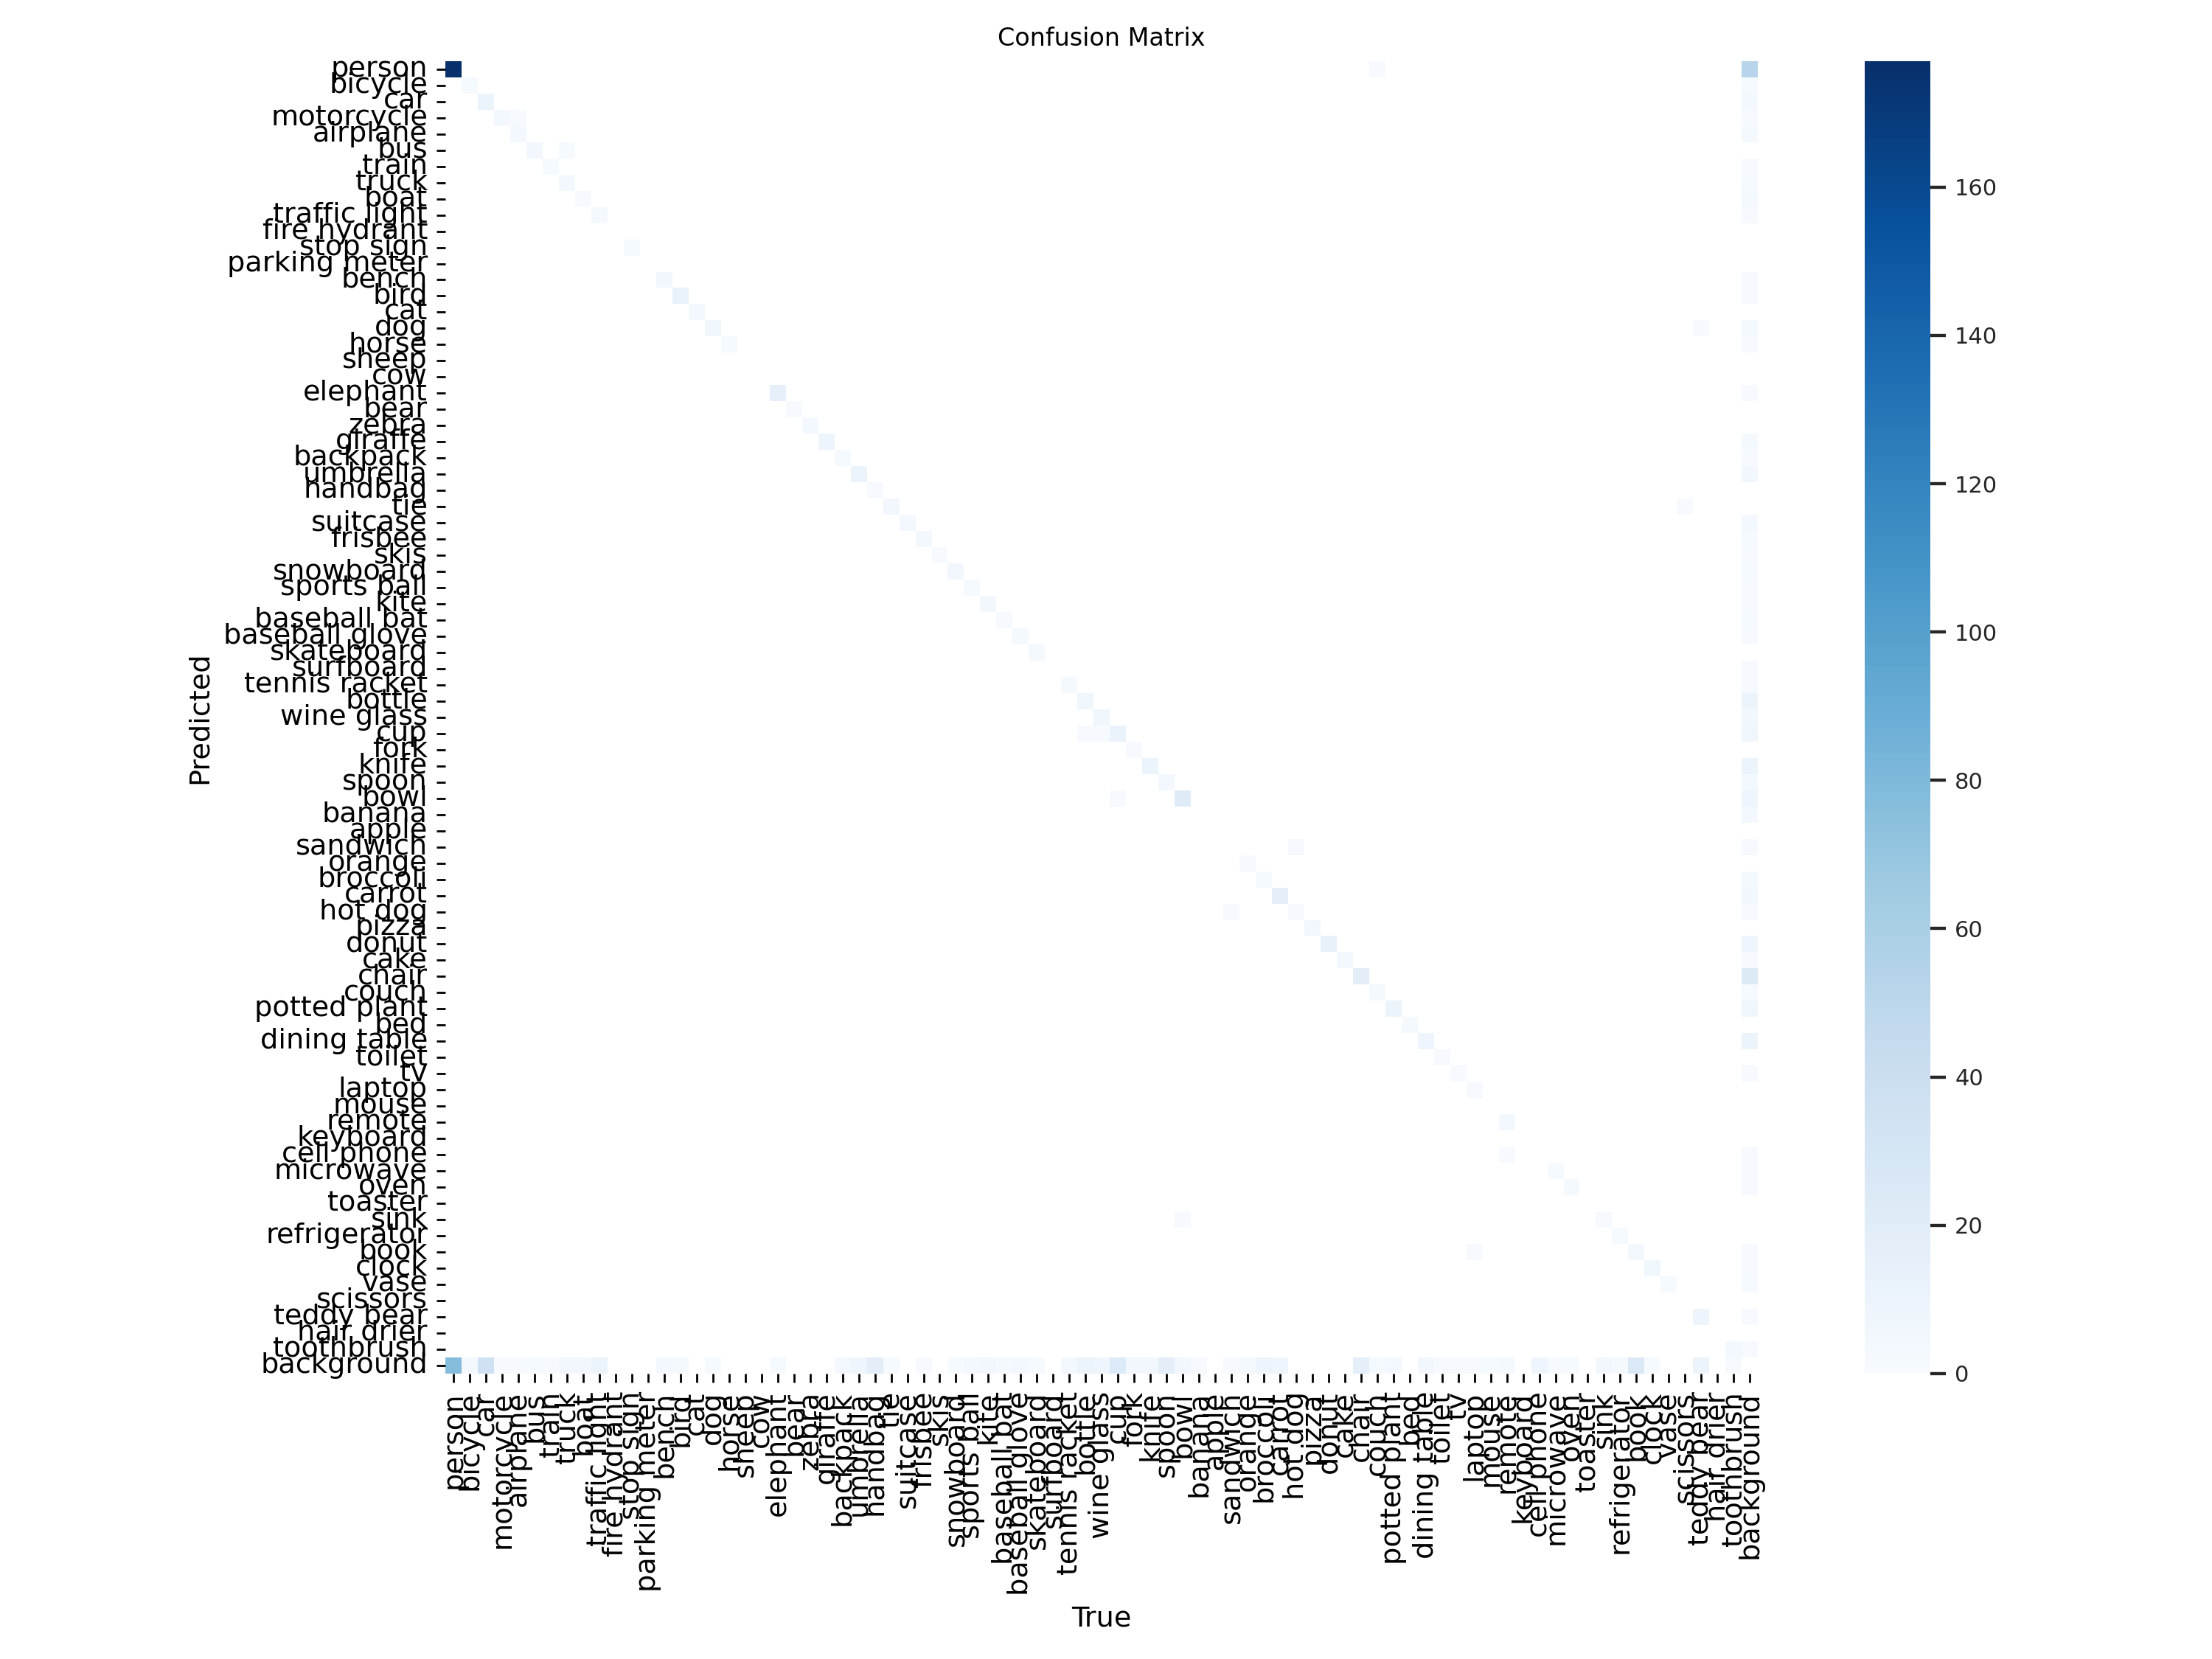

In [13]:
import glob
from IPython.display import Image, display

# Cek apakah ada file Confusion Matrix yang dihasilkan
conf_matrix_path = glob.glob("runs/detect/val/confusion_matrix.png")

if conf_matrix_path:
    print("📊 Menampilkan Confusion Matrix:")
    display(Image(filename=conf_matrix_path[0]))  # Menampilkan gambar Confusion Matrix
else:
    print("⚠️ Confusion Matrix tidak ditemukan. Pastikan validasi sudah dijalankan.")


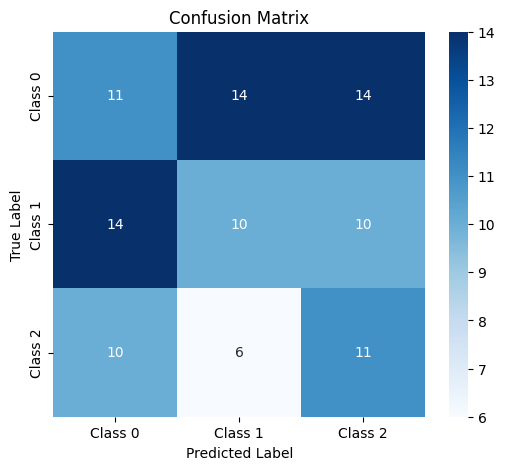

In [14]:
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix

# Simulasi contoh data (gantilah dengan hasil deteksi YOLO sebenarnya)
y_true = np.random.randint(0, 3, 100)  # Label ground truth (misalnya ada 3 kelas)
y_pred = np.random.randint(0, 3, 100)  # Prediksi dari model

# Buat Confusion Matrix
cm = confusion_matrix(y_true, y_pred)

# Plot Confusion Matrix
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=["Class 0", "Class 1", "Class 2"], yticklabels=["Class 0", "Class 1", "Class 2"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()


📸 Menampilkan 3 gambar hasil prediksi:


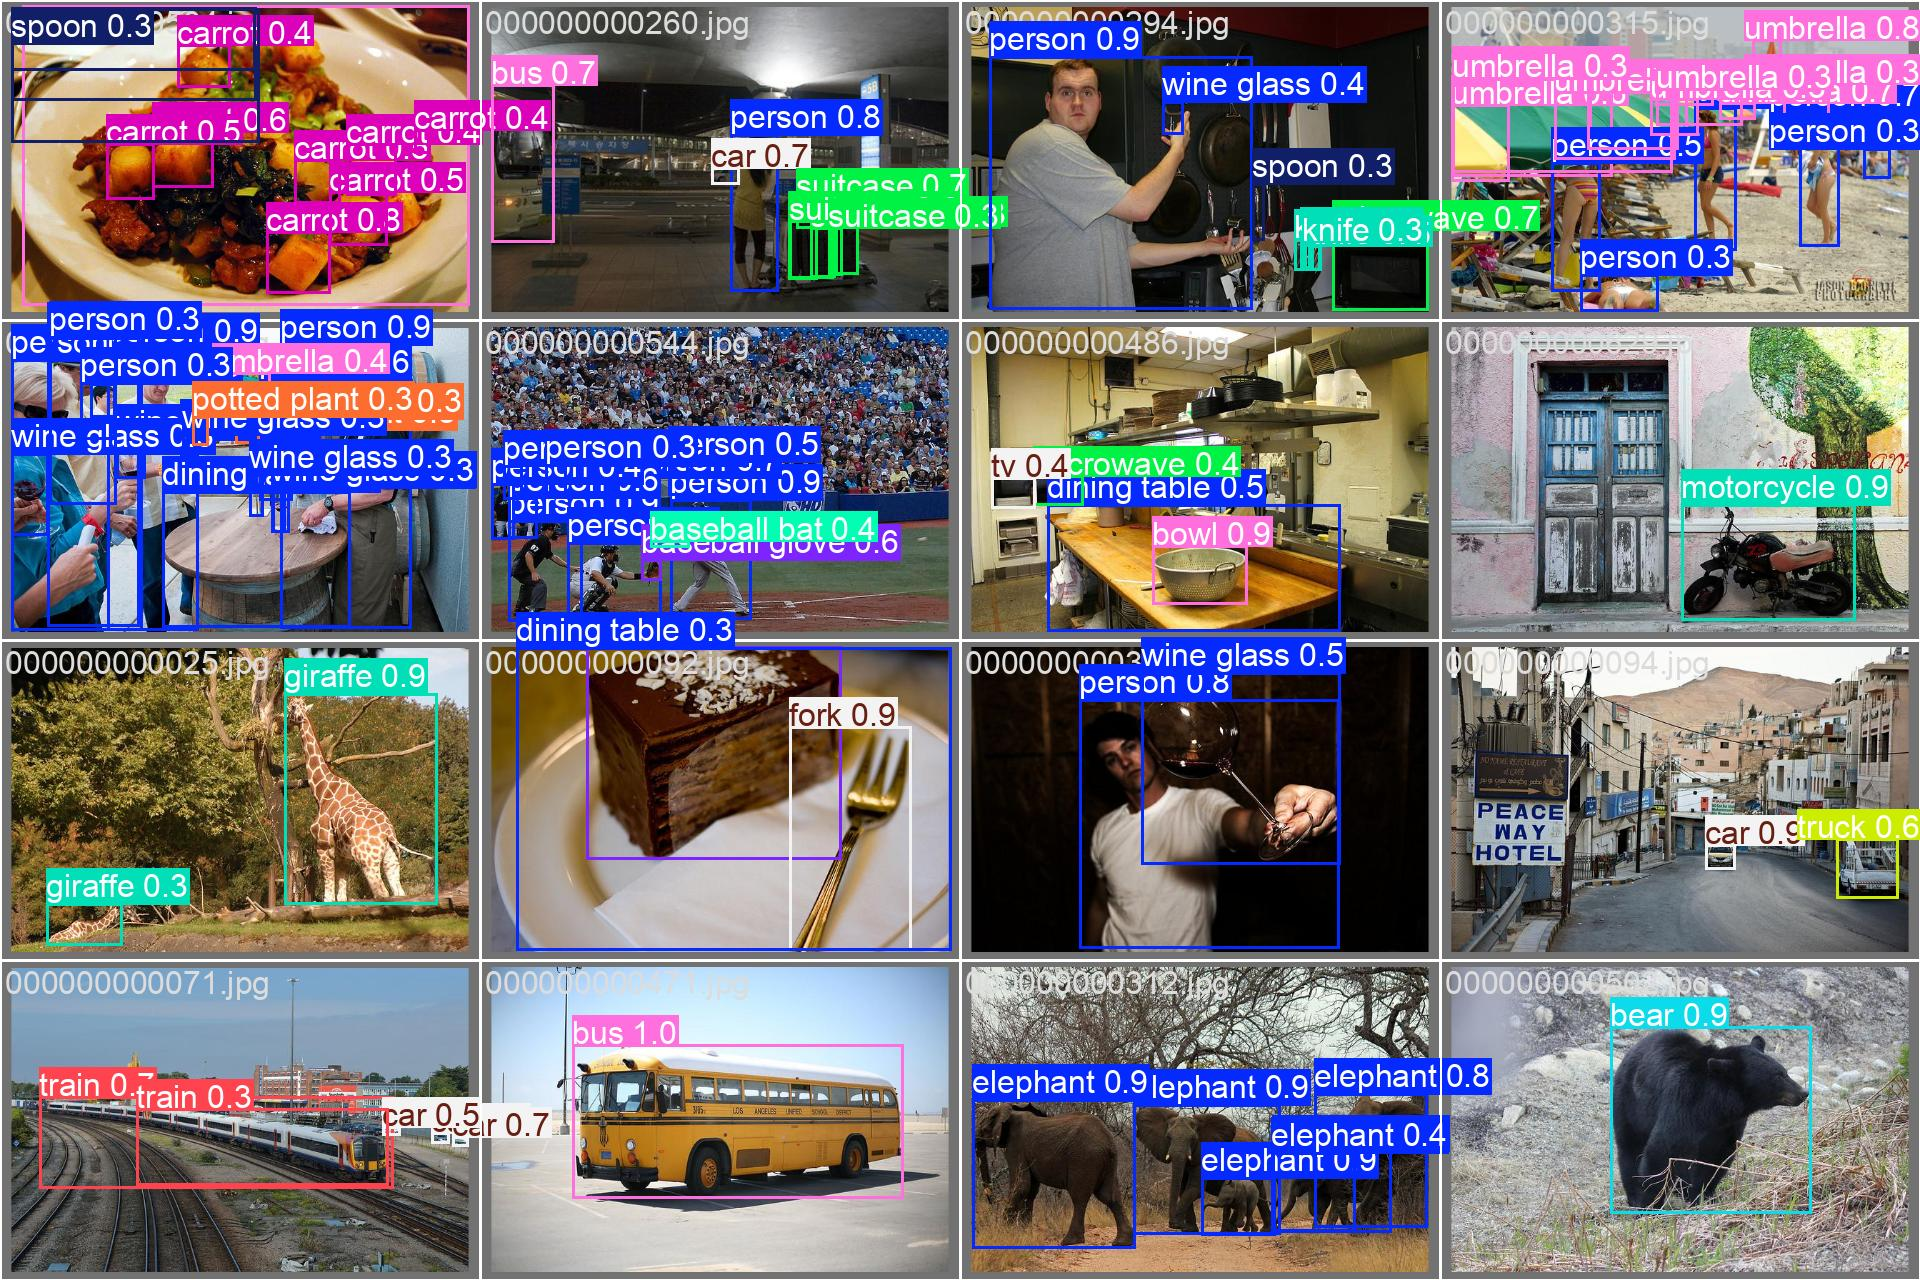

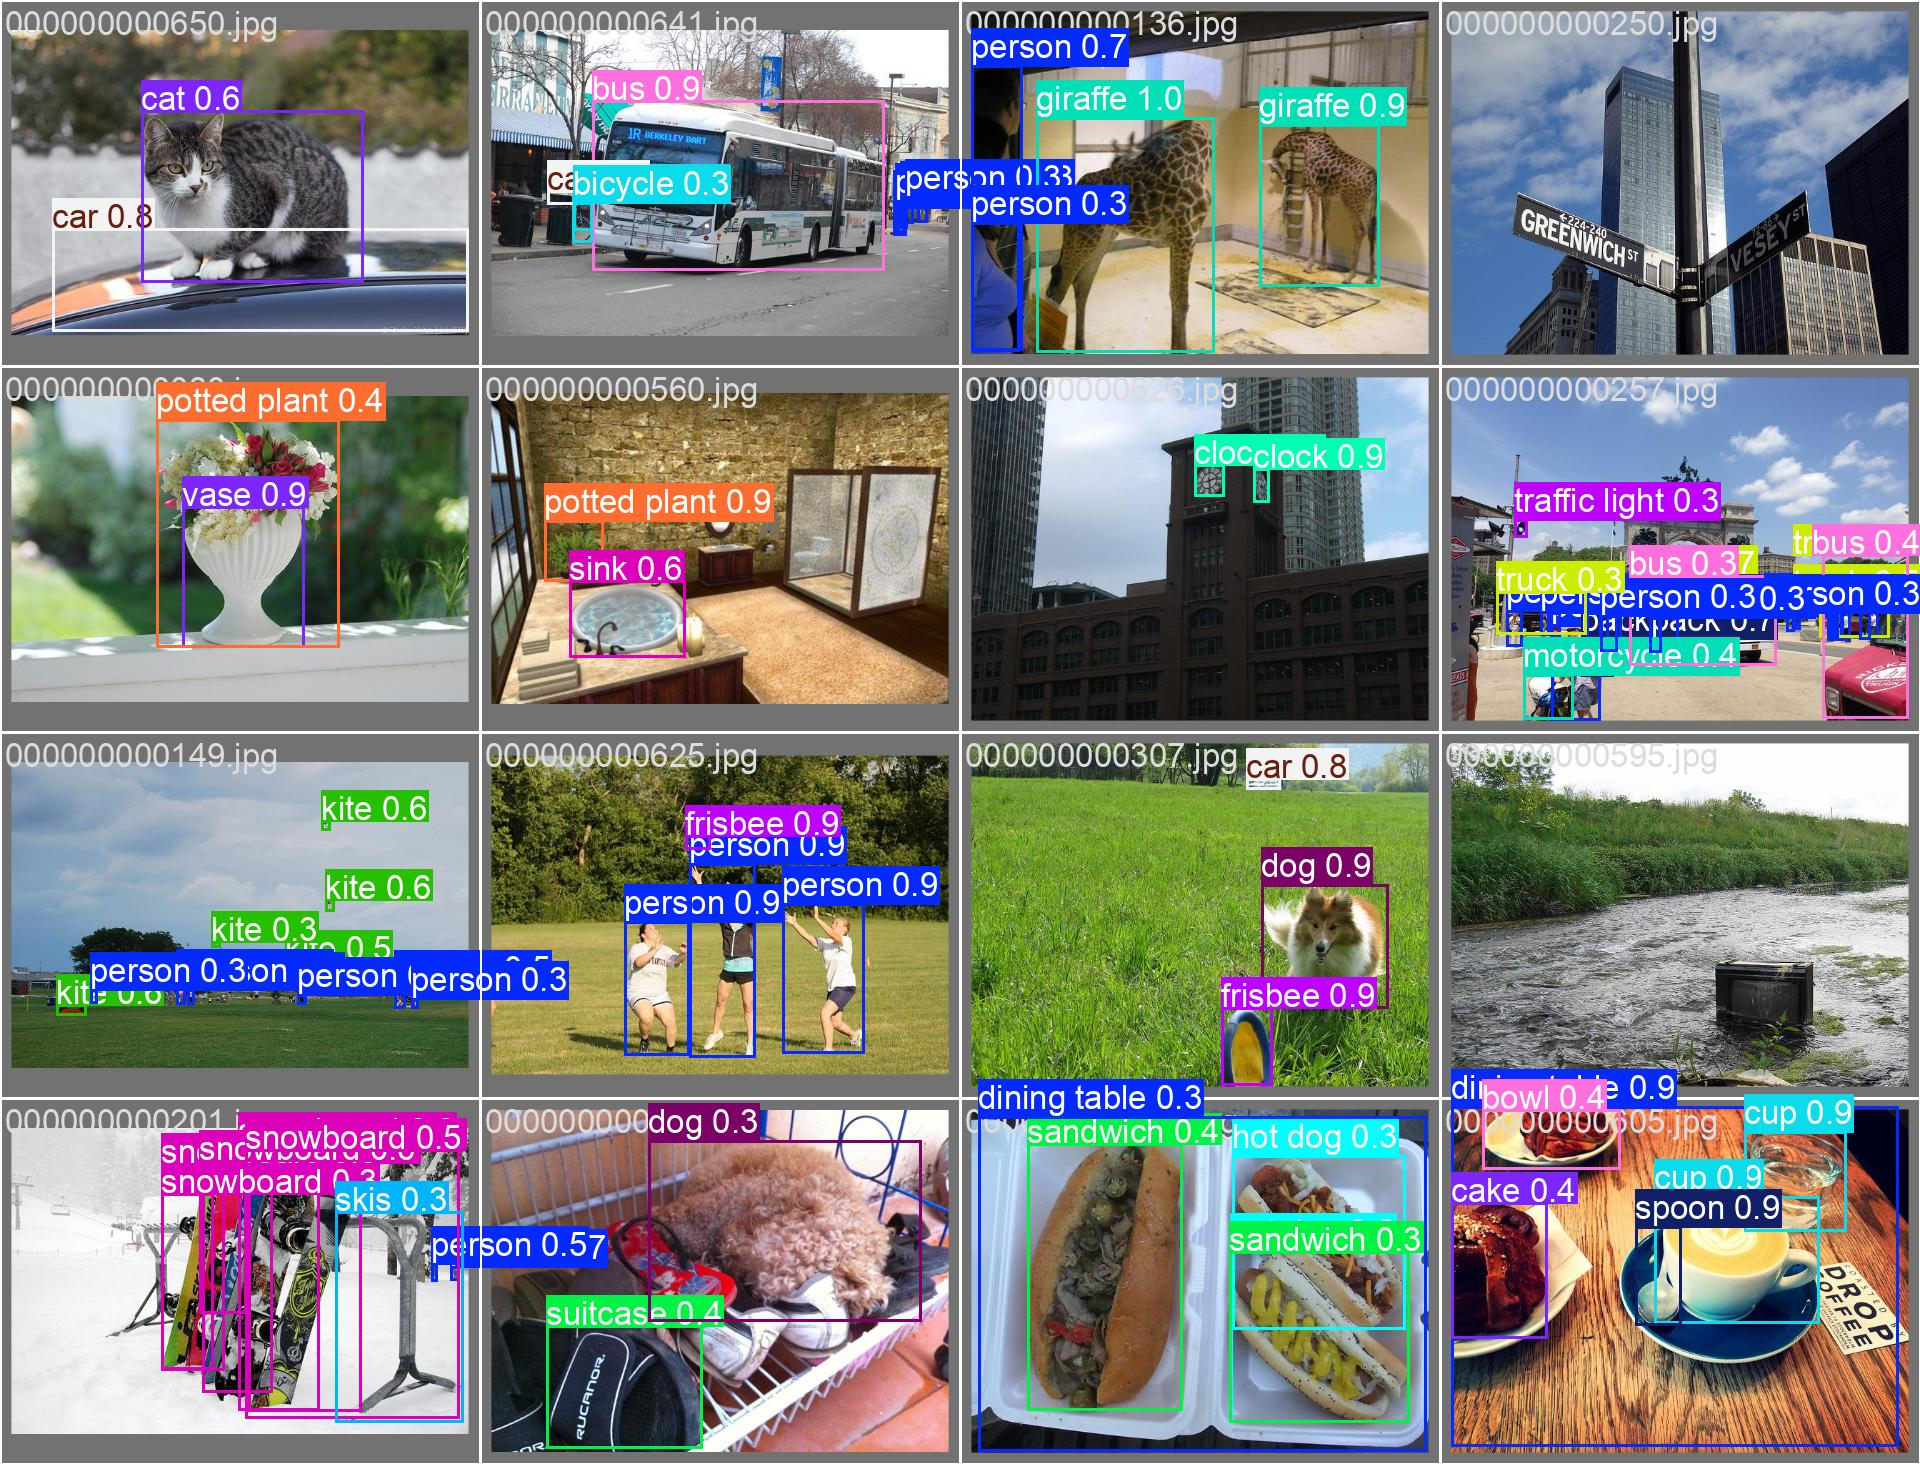

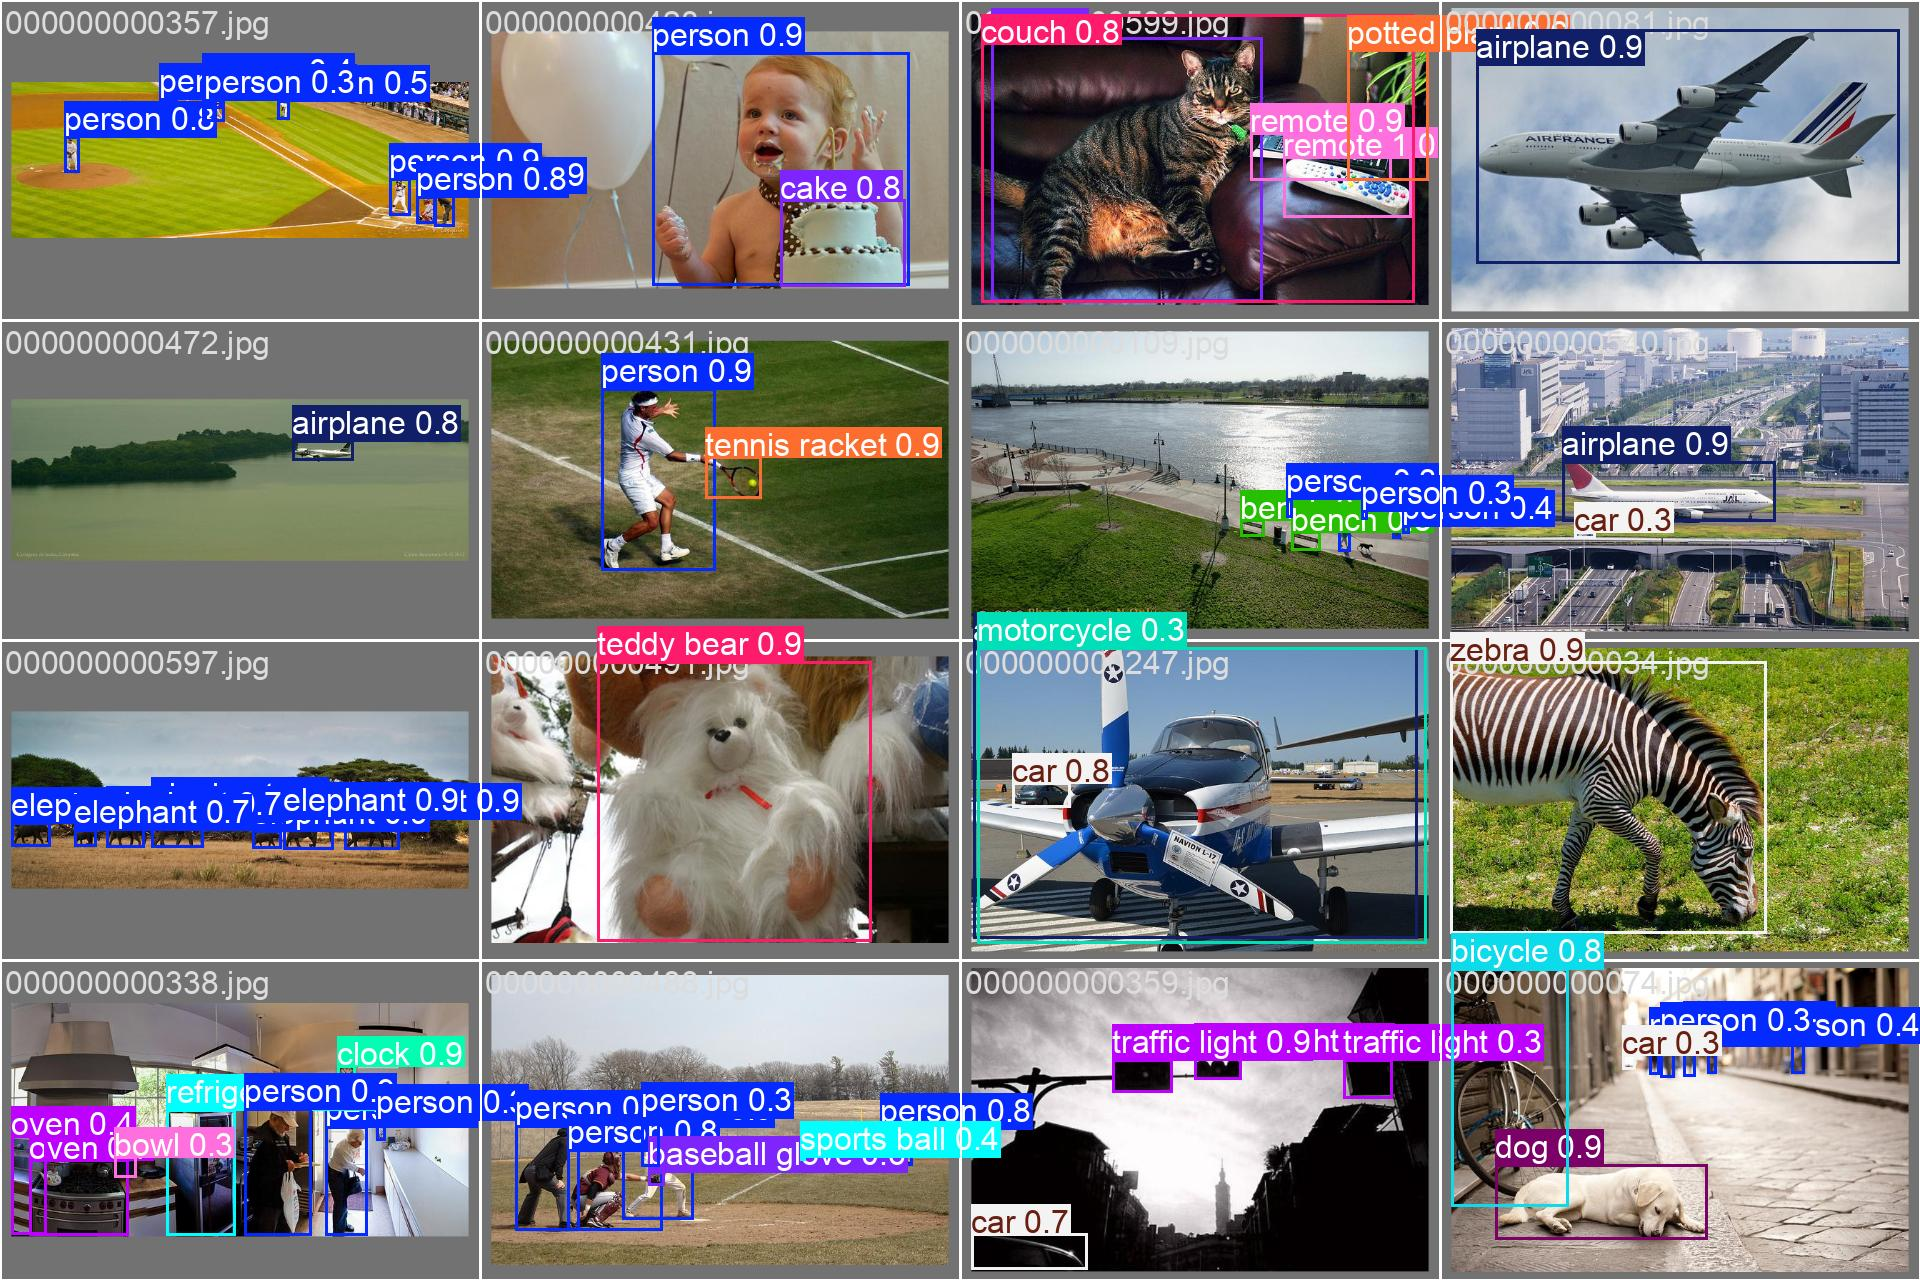

In [15]:
from IPython.display import Image, display
import glob

# Direktori hasil evaluasi (disesuaikan dengan output YOLOv8)
val_dir = "runs/detect/val/"

# Cari gambar hasil prediksi (biasanya disimpan sebagai "val_batchX_pred.jpg")
pred_images = glob.glob(f"{val_dir}/*_pred.jpg")

if pred_images:
    print(f"📸 Menampilkan {len(pred_images)} gambar hasil prediksi:")
    for img_path in pred_images[:5]:  # Menampilkan maksimal 5 gambar pertama
        display(Image(filename=img_path))
else:
    print("⚠️ Tidak ada gambar hasil prediksi yang ditemukan.")
